In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

# Assuming you have a file named 'depression_data.csv' in the root of your Google Drive
# You can adjust the path to your specific file.
file_path = '/content/drive/MyDrive/UPFs_Depression_Final_Raw_Data.csv'

try:
  df = pd.read_csv(file_path)
  print(f'Successfully loaded data from {file_path}. First 5 rows:')
  display(df.head())
except FileNotFoundError:
  print(f'Error: The file {file_path} was not found. Please check the path and filename in your Google Drive.')
except Exception as e:
  print(f'An error occurred while loading the file: {e}')

Successfully loaded data from /content/drive/MyDrive/UPFs_Depression_Final_Raw_Data.csv. First 5 rows:


,age,gender,total_calories,dietary_fiber,sodium,saturated_fat,UPF_percent,PHQ9_score,depression,smoking,...,vitamin_d,BMI,weight,HbA1c,sleep_hours,bmi_category,obesity,high_inflammation,UPF_quartile,high_UPF
0,66,1,2741.0,29.6,5635.0,14.544,52.46,1,0,0,...,60.5,33.5,101.8,5.6,9.0,Obese,1,0,Q3,0
1,44,2,1995.0,21.1,2890.0,26.936,45.26,2,0,0,...,39.4,29.7,69.4,6.2,8.0,Overweight,0,1,Q2,0
2,34,1,2422.0,25.1,4136.0,33.935,45.58,1,0,0,...,96.9,30.2,90.6,5.1,7.5,Obese,1,0,Q2,0
3,68,2,3849.0,22.0,6294.0,49.849,25.18,0,0,0,...,26.7,42.6,103.5,5.9,3.0,Obese,1,1,Q1,0
4,59,1,1991.0,6.7,3481.0,37.373,49.47,0,0,0,...,78.6,28.0,79.8,5.5,8.0,Overweight,0,0,Q3,0


In [5]:
numerical_df = df.select_dtypes(include=['number'])
print("Numerical DataFrame head:")
display(numerical_df.head())

Numerical DataFrame head:


,age,gender,total_calories,dietary_fiber,sodium,saturated_fat,UPF_percent,PHQ9_score,depression,smoking,CRP,folate,vitamin_d,BMI,weight,HbA1c,sleep_hours,obesity,high_inflammation,high_UPF
0,66,1,2741.0,29.6,5635.0,14.544,52.46,1,0,0,2.03,24.3,60.5,33.5,101.8,5.6,9.0,1,0,0
1,44,2,1995.0,21.1,2890.0,26.936,45.26,2,0,0,5.62,25.1,39.4,29.7,69.4,6.2,8.0,0,1,0
2,34,1,2422.0,25.1,4136.0,33.935,45.58,1,0,0,1.05,40.1,96.9,30.2,90.6,5.1,7.5,1,0,0
3,68,2,3849.0,22.0,6294.0,49.849,25.18,0,0,0,3.96,20.2,26.7,42.6,103.5,5.9,3.0,1,1,0
4,59,1,1991.0,6.7,3481.0,37.373,49.47,0,0,0,1.78,33.5,78.6,28.0,79.8,5.5,8.0,0,0,0


In [6]:
correlation_matrix = numerical_df.corr()
print("Correlation Matrix head:")
display(correlation_matrix.head())

Correlation Matrix head:


,age,gender,total_calories,dietary_fiber,sodium,saturated_fat,UPF_percent,PHQ9_score,depression,smoking,CRP,folate,vitamin_d,BMI,weight,HbA1c,sleep_hours,obesity,high_inflammation,high_UPF
age,1.000000,-0.012178,-0.194415,0.008474,-0.174782,-0.129613,-0.197337,-0.048246,-0.024219,-0.076457,0.047623,0.242874,0.248940,0.066395,0.002563,0.292926,0.014096,0.050944,0.065837,-0.156324
gender,-0.012178,1.000000,-0.317468,-0.148703,-0.275133,-0.224403,-0.057291,0.118890,0.072746,-0.081181,0.075315,0.089672,0.071769,0.061156,-0.254189,-0.032204,0.028922,0.062798,0.129386,-0.051487
total_calories,-0.194415,-0.317468,1.000000,0.526699,0.790462,0.812688,0.150301,-0.021920,-0.029874,0.092408,-0.057532,-0.077362,-0.034323,-0.029422,0.117698,-0.070449,-0.026857,-0.024666,-0.067431,0.089212
dietary_fiber,0.008474,-0.148703,0.526699,1.000000,0.453365,0.329823,-0.032208,-0.081481,-0.067980,-0.099900,-0.069017,0.074303,0.060117,-0.062059,-0.006433,-0.006284,0.000873,-0.058198,-0.085264,-0.050638
sodium,-0.174782,-0.275133,0.790462,0.453365,1.000000,0.691583,0.113293,-0.036542,-0.044780,0.044295,-0.040684,-0.056415,-0.045174,0.003366,0.131810,-0.035171,-0.017028,0.008650,-0.052653,0.070642


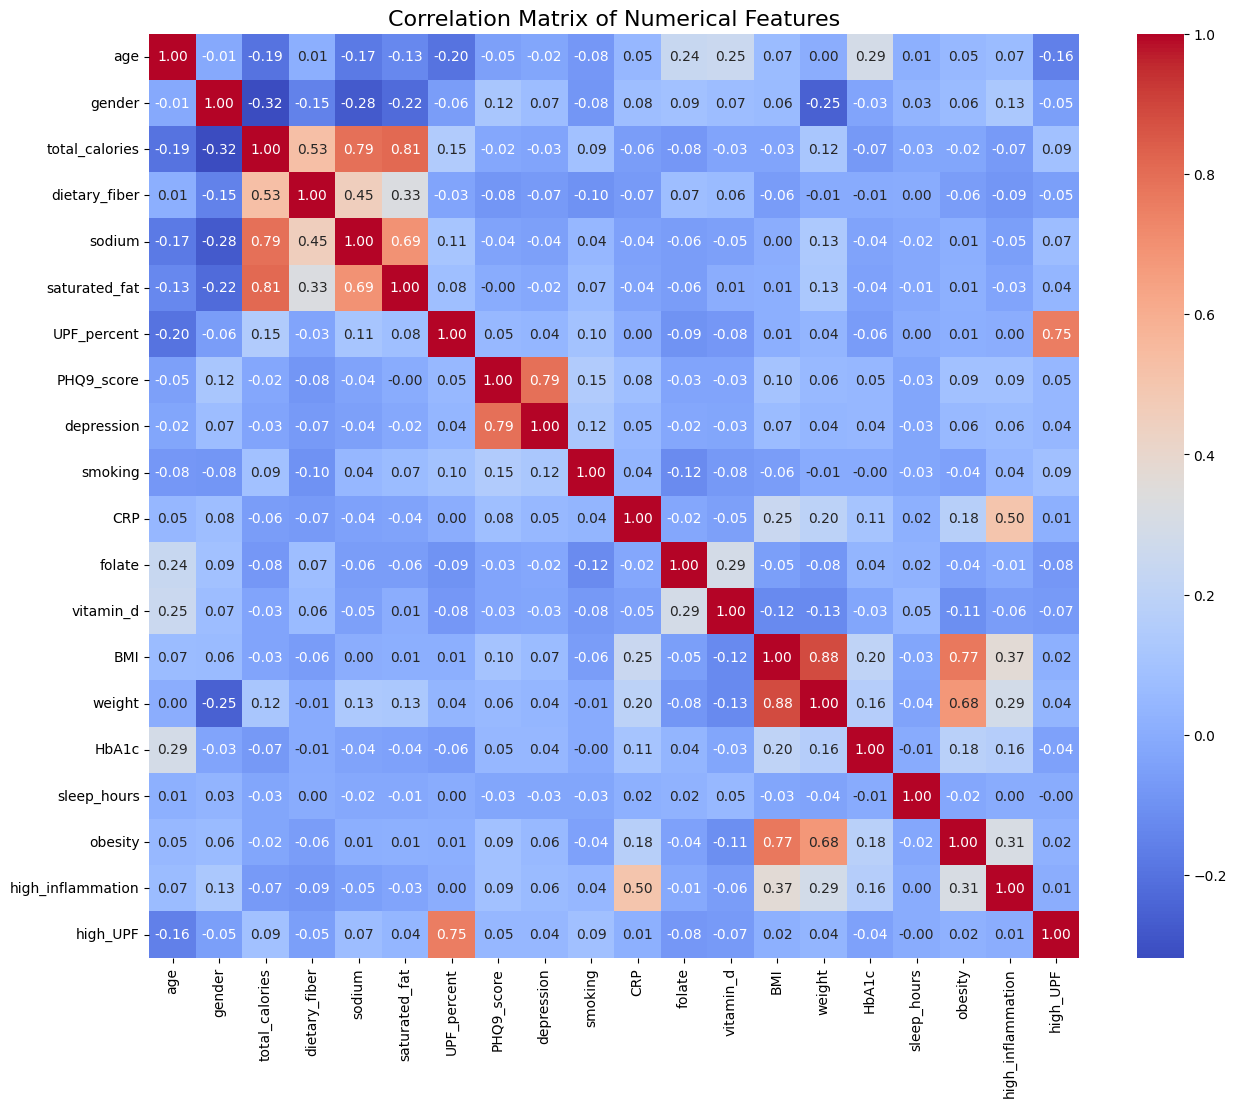

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

In [8]:
columns_to_drop = ['depression', 'weight', 'high_UPF', 'obesity']

# Create a new DataFrame by dropping the specified columns from numerical_df
df_reduced = numerical_df.drop(columns=columns_to_drop)

print("New DataFrame head after dropping variables:")
display(df_reduced.head())

New DataFrame head after dropping variables:


,age,gender,total_calories,dietary_fiber,sodium,saturated_fat,UPF_percent,PHQ9_score,smoking,CRP,folate,vitamin_d,BMI,HbA1c,sleep_hours,high_inflammation
0,66,1,2741.0,29.6,5635.0,14.544,52.46,1,0,2.03,24.3,60.5,33.5,5.6,9.0,0
1,44,2,1995.0,21.1,2890.0,26.936,45.26,2,0,5.62,25.1,39.4,29.7,6.2,8.0,1
2,34,1,2422.0,25.1,4136.0,33.935,45.58,1,0,1.05,40.1,96.9,30.2,5.1,7.5,0
3,68,2,3849.0,22.0,6294.0,49.849,25.18,0,0,3.96,20.2,26.7,42.6,5.9,3.0,1
4,59,1,1991.0,6.7,3481.0,37.373,49.47,0,0,1.78,33.5,78.6,28.0,5.5,8.0,0


--- Distribution of PHQ9_score (Target Variable) ---
PHQ9_score
0     9368
1     4374
2     3656
3     2754
4     1988
5     1471
6     1263
7      920
8      747
9      599
10     505
11     380
12     341
13     275
14     234
15     192
16     155
17     144
18     121
19     108
21      69
20      56
22      45
24      38
23      32
25      17
27       9
26       8
Name: count, dtype: int64




/tmp/ipykernel_7913/3321540813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PHQ9_score', data=df_reduced, palette='viridis')


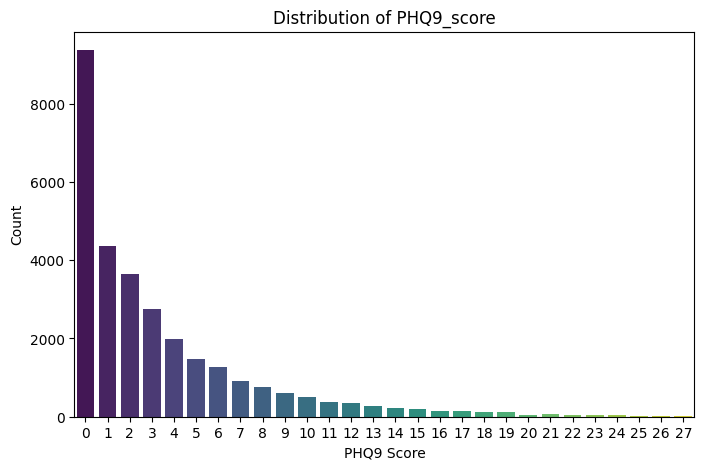

In [9]:
print('--- Distribution of PHQ9_score (Target Variable) ---')
print(df_reduced['PHQ9_score'].value_counts())
print('\n')

plt.figure(figsize=(8, 5))
sns.countplot(x='PHQ9_score', data=df_reduced, palette='viridis')
plt.title('Distribution of PHQ9_score')
plt.xlabel('PHQ9 Score')
plt.ylabel('Count')
plt.show()

--- Balance of Categorical Predictor Variables in df_reduced ---

Distribution for gender:
gender
2    15401
1    14468
Name: count, dtype: int64
Percentage distribution for gender:
gender
2    51.56182
1    48.43818
Name: proportion, dtype: float64


/tmp/ipykernel_7913/2046198510.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_reduced, palette='magma')


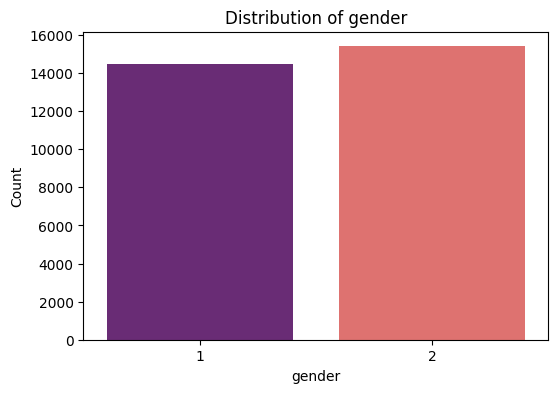


Distribution for smoking:
smoking
0    24299
1     5570
Name: count, dtype: int64
Percentage distribution for smoking:
smoking
0    81.351903
1    18.648097
Name: proportion, dtype: float64


/tmp/ipykernel_7913/2046198510.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_reduced, palette='magma')


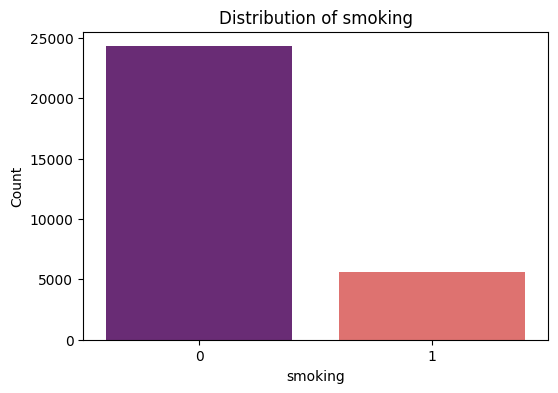


Distribution for high_inflammation:
high_inflammation
0    19552
1    10317
Name: count, dtype: int64
Percentage distribution for high_inflammation:
high_inflammation
0    65.459172
1    34.540828
Name: proportion, dtype: float64


/tmp/ipykernel_7913/2046198510.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_reduced, palette='magma')


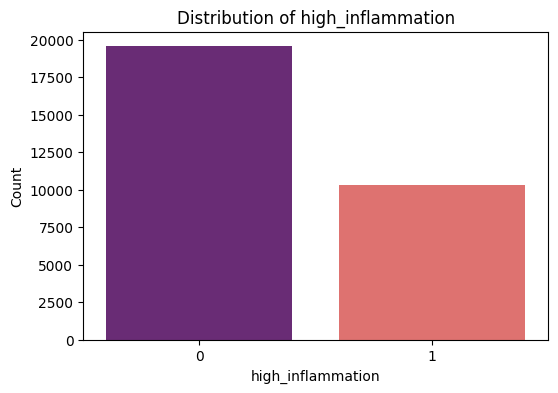

In [10]:
print('--- Balance of Categorical Predictor Variables in df_reduced ---')

categorical_cols = [
    'gender', 'smoking', 'high_inflammation' # These are likely binary/categorical
]

for col in categorical_cols:
    if col in df_reduced.columns:
        print(f'\nDistribution for {col}:')
        print(df_reduced[col].value_counts())
        print(f'Percentage distribution for {col}:')
        print(df_reduced[col].value_counts(normalize=True) * 100)
        plt.figure(figsize=(6, 4))
        sns.countplot(x=col, data=df_reduced, palette='magma')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()
    else:
        print(f'Column {col} not found in df_reduced.')


--- Distribution of Continuous Predictor Variables in df_reduced ---

Descriptive Statistics:


,age,total_calories,dietary_fiber,sodium,saturated_fat,UPF_percent,CRP,folate,vitamin_d,BMI,HbA1c,sleep_hours
count,29869.000000,2.986900e+04,2.986900e+04,29869.000000,2.986900e+04,29869.000000,29869.000000,29869.000000,29869.000000,29869.000000,29869.000000,29869.000000
mean,48.810004,2.094174e+03,1.628439e+01,3380.867957,2.648982e+01,47.168898,4.071091,39.418427,65.956731,29.244346,5.718518,7.308614
std,18.790615,9.943115e+02,1.028741e+01,1824.801913,1.703092e+01,23.112490,7.728956,28.215772,28.939677,7.005075,1.049266,2.843360
min,18.000000,5.397605e-79,5.397605e-79,1.000000,5.397605e-79,0.000000,0.080000,1.600000,5.490000,11.100000,2.000000,1.000000
25%,32.000000,1.419000e+03,9.200000e+00,2141.000000,1.477400e+01,30.020000,0.800000,23.800000,46.600000,24.400000,5.200000,6.000000
50%,49.000000,1.927000e+03,1.420000e+01,3044.000000,2.298700e+01,46.880000,1.900000,33.500000,61.500000,28.100000,5.500000,7.000000
75%,64.000000,2.575000e+03,2.080000e+01,4221.000000,3.429100e+01,63.720000,4.300000,46.800000,79.800000,32.710000,5.800000,8.000000
max,85.000000,1.350900e+04,1.476000e+02,25949.000000,2.381270e+02,100.000000,200.000000,1390.000000,422.000000,130.210000,17.100000,99.000000



Histograms for Continuous Variables:


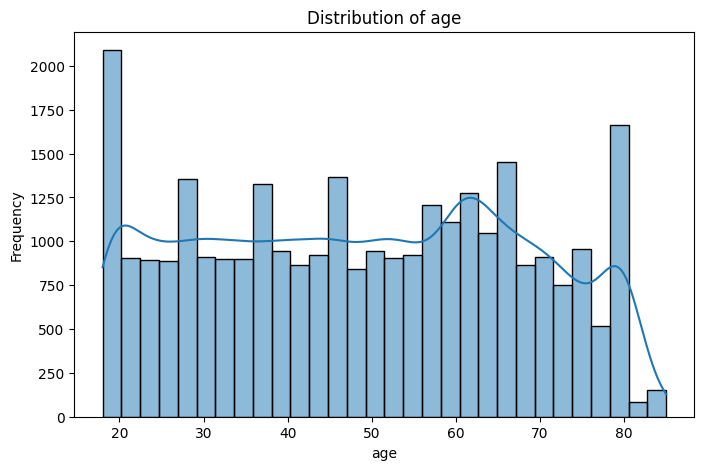

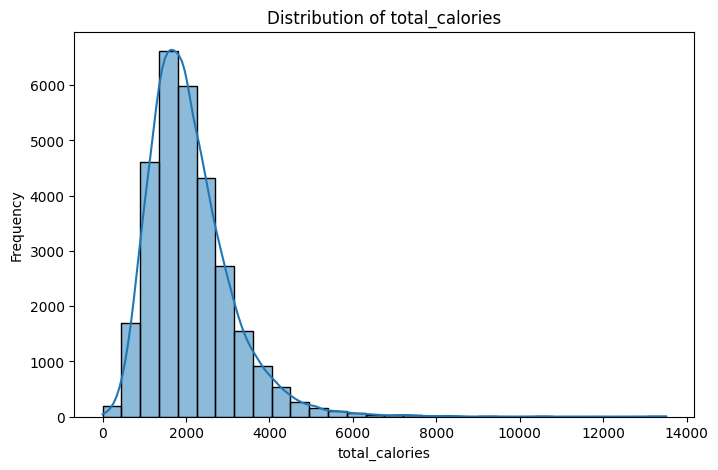

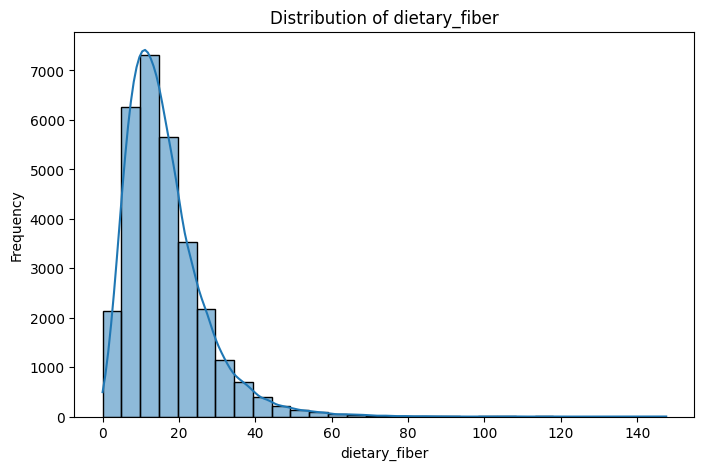

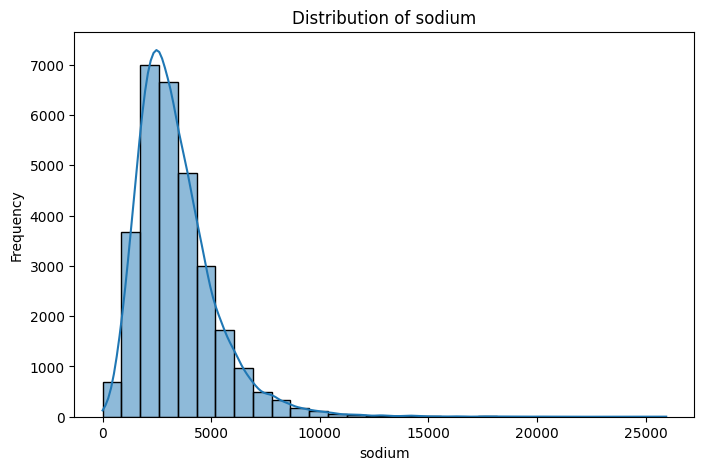

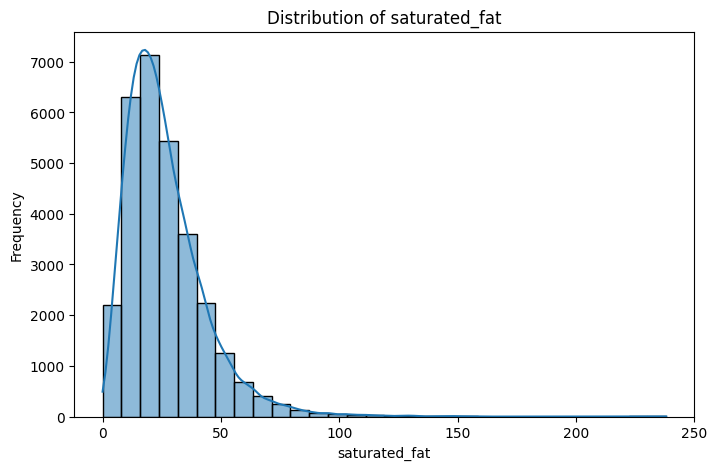

In [11]:
print('\n--- Distribution of Continuous Predictor Variables in df_reduced ---')

# Exclude 'PHQ9_score' and known categorical columns for descriptive statistics
continuous_cols = [col for col in df_reduced.columns if col not in ['PHQ9_score', 'gender', 'smoking', 'high_inflammation']]

if continuous_cols:
    print('\nDescriptive Statistics:')
    display(df_reduced[continuous_cols].describe())

    print('\nHistograms for Continuous Variables:')
    # Plotting histograms for a few continuous variables to check their distribution
    for col in continuous_cols[:5]: # Displaying first 5 for brevity
        plt.figure(figsize=(8, 5))
        sns.histplot(df_reduced[col].dropna(), kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()
else:
    print('No continuous predictor variables found in df_reduced.')

In [12]:
bins = [-1, 4, 9, 14, 19, 27]
labels = [
    'Minimal Depression',
    'Mild Depression',
    'Moderate Depression',
    'Moderately Severe Depression',
    'Severe Depression'
]

df_reduced['PHQ9_severity'] = pd.cut(
    df_reduced['PHQ9_score'],
    bins=bins,
    labels=labels,
    right=True
)

print("Distribution of PHQ9_severity:")
display(df_reduced['PHQ9_severity'].value_counts())
print("First 5 rows of df_reduced with new PHQ9_severity column:")
display(df_reduced.head())

Distribution of PHQ9_severity:


,count
PHQ9_severity,
Minimal Depression,22140
Mild Depression,5000
Moderate Depression,1735
Moderately Severe Depression,720
Severe Depression,274


First 5 rows of df_reduced with new PHQ9_severity column:


,age,gender,total_calories,dietary_fiber,sodium,saturated_fat,UPF_percent,PHQ9_score,smoking,CRP,folate,vitamin_d,BMI,HbA1c,sleep_hours,high_inflammation,PHQ9_severity
0,66,1,2741.0,29.6,5635.0,14.544,52.46,1,0,2.03,24.3,60.5,33.5,5.6,9.0,0,Minimal Depression
1,44,2,1995.0,21.1,2890.0,26.936,45.26,2,0,5.62,25.1,39.4,29.7,6.2,8.0,1,Minimal Depression
2,34,1,2422.0,25.1,4136.0,33.935,45.58,1,0,1.05,40.1,96.9,30.2,5.1,7.5,0,Minimal Depression
3,68,2,3849.0,22.0,6294.0,49.849,25.18,0,0,3.96,20.2,26.7,42.6,5.9,3.0,1,Minimal Depression
4,59,1,1991.0,6.7,3481.0,37.373,49.47,0,0,1.78,33.5,78.6,28.0,5.5,8.0,0,Minimal Depression


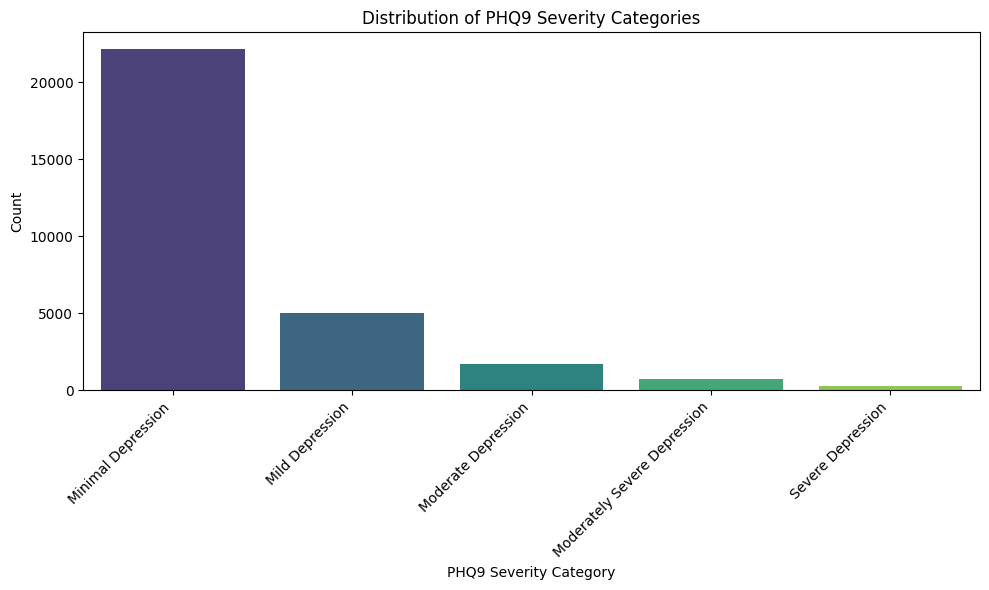

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(x='PHQ9_severity', data=df_reduced, hue='PHQ9_severity', palette='viridis', order=labels, legend=False)
plt.title('Distribution of PHQ9 Severity Categories')
plt.xlabel('PHQ9 Severity Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
X = df_reduced.drop(['PHQ9_score', 'PHQ9_severity'], axis=1)
y = df_reduced['PHQ9_severity']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("X head:")
display(X.head())
print("y head:")
display(y.head())

Shape of X: (29869, 15)
Shape of y: (29869,)
X head:


,age,gender,total_calories,dietary_fiber,sodium,saturated_fat,UPF_percent,smoking,CRP,folate,vitamin_d,BMI,HbA1c,sleep_hours,high_inflammation
0,66,1,2741.0,29.6,5635.0,14.544,52.46,0,2.03,24.3,60.5,33.5,5.6,9.0,0
1,44,2,1995.0,21.1,2890.0,26.936,45.26,0,5.62,25.1,39.4,29.7,6.2,8.0,1
2,34,1,2422.0,25.1,4136.0,33.935,45.58,0,1.05,40.1,96.9,30.2,5.1,7.5,0
3,68,2,3849.0,22.0,6294.0,49.849,25.18,0,3.96,20.2,26.7,42.6,5.9,3.0,1
4,59,1,1991.0,6.7,3481.0,37.373,49.47,0,1.78,33.5,78.6,28.0,5.5,8.0,0


y head:


,PHQ9_severity
0,Minimal Depression
1,Minimal Depression
2,Minimal Depression
3,Minimal Depression
4,Minimal Depression


In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Shape of X_resampled:", X_resampled.shape)
print("Shape of y_resampled:", y_resampled.shape)
print("Original distribution of PHQ9_severity:")
display(y.value_counts())
print("Resampled distribution of PHQ9_severity:")
display(y_resampled.value_counts())


Shape of X_resampled: (110700, 15)
Shape of y_resampled: (110700,)
Original distribution of PHQ9_severity:


,count
PHQ9_severity,
Minimal Depression,22140
Mild Depression,5000
Moderate Depression,1735
Moderately Severe Depression,720
Severe Depression,274


Resampled distribution of PHQ9_severity:


,count
PHQ9_severity,
Minimal Depression,22140
Mild Depression,22140
Moderate Depression,22140
Moderately Severe Depression,22140
Severe Depression,22140


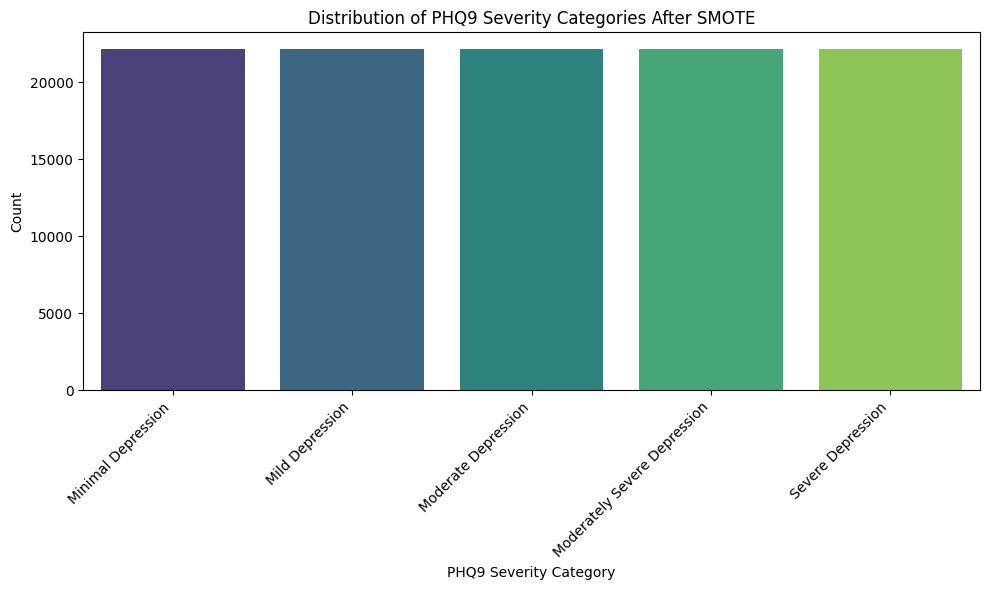

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(x=y_resampled, hue=y_resampled, palette='viridis', order=labels, legend=False)
plt.title('Distribution of PHQ9 Severity Categories After SMOTE')
plt.xlabel('PHQ9 Severity Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
print("Shape of X_resampled:", X_resampled.shape)
print("Shape of y_resampled:", y_resampled.shape)

Shape of X_resampled: (110700, 15)
Shape of y_resampled: (110700,)


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the resampled data
correlation_matrix_resampled = X_resampled.corr()

print("Correlation Matrix After SMOTE (head):")
display(correlation_matrix_resampled.head())

Correlation Matrix After SMOTE (head):


,age,gender,total_calories,dietary_fiber,sodium,saturated_fat,UPF_percent,smoking,CRP,folate,vitamin_d,BMI,HbA1c,sleep_hours,high_inflammation
age,1.000000,0.006188,-0.188114,-0.020389,-0.179271,-0.134200,-0.181780,-0.051452,0.055785,0.187589,0.233407,0.053616,0.290883,0.014992,0.072423
gender,0.006188,1.000000,-0.313729,-0.174476,-0.270246,-0.256742,-0.040128,-0.031941,0.037260,0.048399,0.042860,0.057232,-0.022830,0.004329,0.086561
total_calories,-0.188114,-0.313729,1.000000,0.612952,0.806151,0.854205,0.112320,0.052658,-0.039446,-0.027756,-0.017884,-0.038783,-0.073989,-0.005424,-0.057244
dietary_fiber,-0.020389,-0.174476,0.612952,1.000000,0.555375,0.460284,-0.043558,-0.069449,-0.088814,0.087026,0.040651,-0.052216,-0.018563,0.025050,-0.063112
sodium,-0.179271,-0.270246,0.806151,0.555375,1.000000,0.743596,0.081582,0.002446,-0.034057,-0.001806,-0.024539,0.004796,-0.030840,0.005439,-0.044722


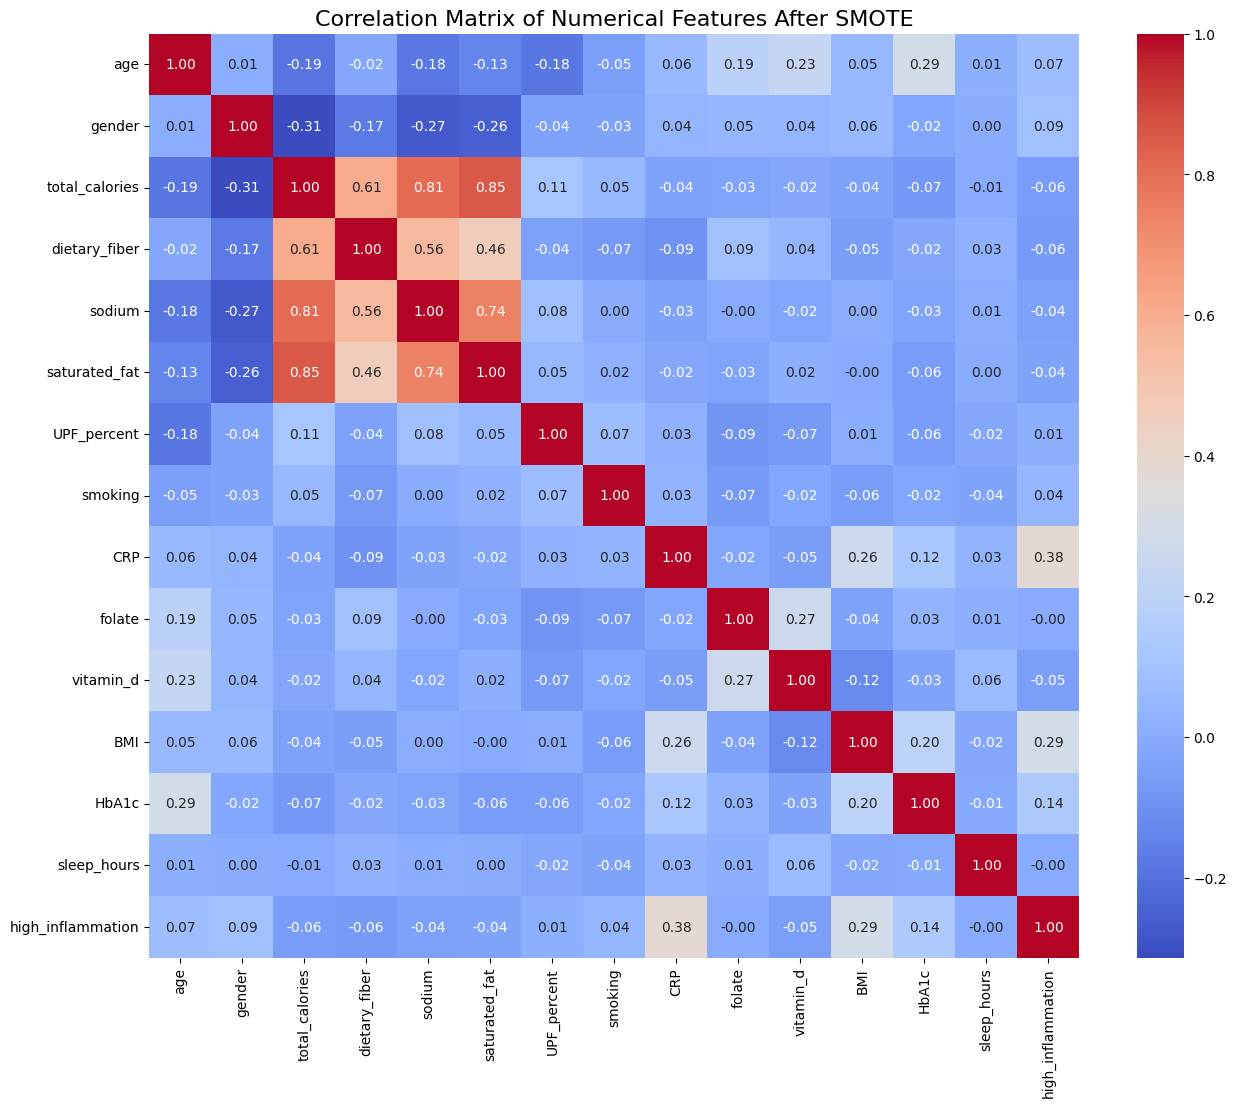

Heatmap of Correlation Matrix After SMOTE generated.


In [19]:
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix_resampled, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features After SMOTE', fontsize=16)
plt.show()

print("Heatmap of Correlation Matrix After SMOTE generated.")

In [20]:
# Identify the columns that are common to X_resampled and numerical_df
common_cols = X_resampled.columns.intersection(numerical_df.columns)

# Filter numerical_df to include only these common columns
numerical_df_filtered = numerical_df[common_cols]

# Calculate the correlation matrix for the filtered original data
correlation_matrix_original_filtered = numerical_df_filtered.corr()

print("Correlation Matrix Before SMOTE (filtered variables, head):")
display(correlation_matrix_original_filtered.head())

Correlation Matrix Before SMOTE (filtered variables, head):


,age,gender,total_calories,dietary_fiber,sodium,saturated_fat,UPF_percent,smoking,CRP,folate,vitamin_d,BMI,HbA1c,sleep_hours,high_inflammation
age,1.000000,-0.012178,-0.194415,0.008474,-0.174782,-0.129613,-0.197337,-0.076457,0.047623,0.242874,0.248940,0.066395,0.292926,0.014096,0.065837
gender,-0.012178,1.000000,-0.317468,-0.148703,-0.275133,-0.224403,-0.057291,-0.081181,0.075315,0.089672,0.071769,0.061156,-0.032204,0.028922,0.129386
total_calories,-0.194415,-0.317468,1.000000,0.526699,0.790462,0.812688,0.150301,0.092408,-0.057532,-0.077362,-0.034323,-0.029422,-0.070449,-0.026857,-0.067431
dietary_fiber,0.008474,-0.148703,0.526699,1.000000,0.453365,0.329823,-0.032208,-0.099900,-0.069017,0.074303,0.060117,-0.062059,-0.006284,0.000873,-0.085264
sodium,-0.174782,-0.275133,0.790462,0.453365,1.000000,0.691583,0.113293,0.044295,-0.040684,-0.056415,-0.045174,0.003366,-0.035171,-0.017028,-0.052653


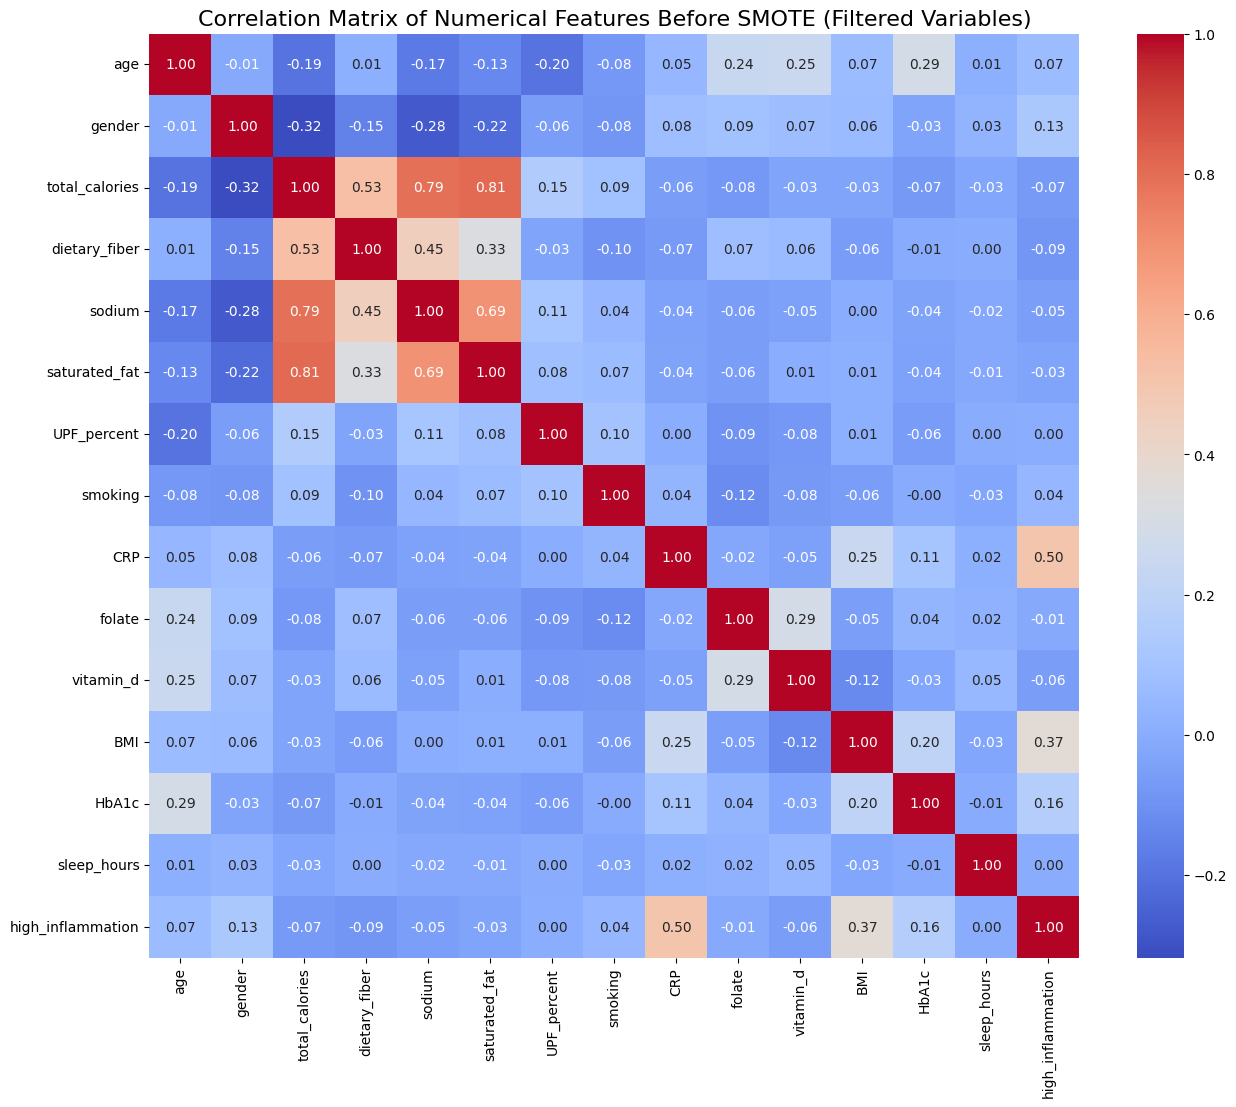

Heatmap of Correlation Matrix Before SMOTE (filtered variables) generated.


In [21]:
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix_original_filtered, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features Before SMOTE (Filtered Variables)', fontsize=16)
plt.show()

print("Heatmap of Correlation Matrix Before SMOTE (filtered variables) generated.")

### Comparison of Correlation Heatmaps: Before vs. After SMOTE (using consistent features)

By comparing the 'Correlation Matrix of Numerical Features Before SMOTE (Filtered Variables)' with the 'Correlation Matrix of Numerical Features After SMOTE', we can observe the direct impact of the SMOTE oversampling technique on the relationships between features.

SMOTE generates synthetic samples for minority classes, which can alter the statistical properties of the dataset, including feature correlations. A significant change in correlations could indicate that the synthetic data points are either reinforcing existing relationships or introducing new ones. Observing features where correlations have changed notably will be key to understanding SMOTE's effect on the feature space, which is crucial before proceeding with model training.

### Comparison of Correlation Heatmaps (Before and After SMOTE)

Upon visual inspection of the 'Correlation Matrix of Numerical Features After SMOTE' and the 'Correlation Matrix of Numerical Features' (before SMOTE), we can observe how the correlations between features might have changed due to the oversampling process.

SMOTE synthesizes new samples for minority classes based on their existing neighbors. While it directly operates on the features and aims to balance the target variable, it can indirectly influence the feature correlations. This is because the synthetic samples introduce new data points in the feature space, potentially strengthening or weakening relationships between features, especially if the original data had sparse or uneven distributions for certain feature combinations.

By comparing both heatmaps, we can assess if SMOTE has inadvertently introduced any spurious correlations or significantly altered the existing ones, which is an important consideration when evaluating the integrity of the feature space after oversampling.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled # Ensure class distribution is maintained
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nDistribution of y_train:")
display(y_train.value_counts(normalize=True))
print("\nDistribution of y_test:")
display(y_test.value_counts(normalize=True))

Shape of X_train: (88560, 15)
Shape of X_test: (22140, 15)
Shape of y_train: (88560,)
Shape of y_test: (22140,)

Distribution of y_train:


,proportion
PHQ9_severity,
Minimal Depression,0.2
Mild Depression,0.2
Moderate Depression,0.2
Moderately Severe Depression,0.2
Severe Depression,0.2



Distribution of y_test:


,proportion
PHQ9_severity,
Minimal Depression,0.2
Mild Depression,0.2
Moderate Depression,0.2
Moderately Severe Depression,0.2
Severe Depression,0.2


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (88560, 15)
Shape of X_test_scaled: (22140, 15)


In [24]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier
model = RandomForestClassifier(random_state=42)

# Fit the model to the training data
model.fit(X_train_scaled, y_train)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


In [25]:
y_pred = model.predict(X_test_scaled)
print("First 5 predictions:")
print(y_pred[:5])

First 5 predictions:
['Severe Depression' 'Severe Depression' 'Moderately Severe Depression'
 'Minimal Depression' 'Moderately Severe Depression']


Classification Report:
                              precision    recall  f1-score   support

          Minimal Depression       0.86      0.75      0.80      4428
             Mild Depression       0.79      0.88      0.83      4428
         Moderate Depression       0.91      0.90      0.91      4428
Moderately Severe Depression       0.96      0.97      0.97      4428
           Severe Depression       0.99      1.00      0.99      4428

                    accuracy                           0.90     22140
                   macro avg       0.90      0.90      0.90     22140
                weighted avg       0.90      0.90      0.90     22140


Accuracy Score: 0.9004516711833785


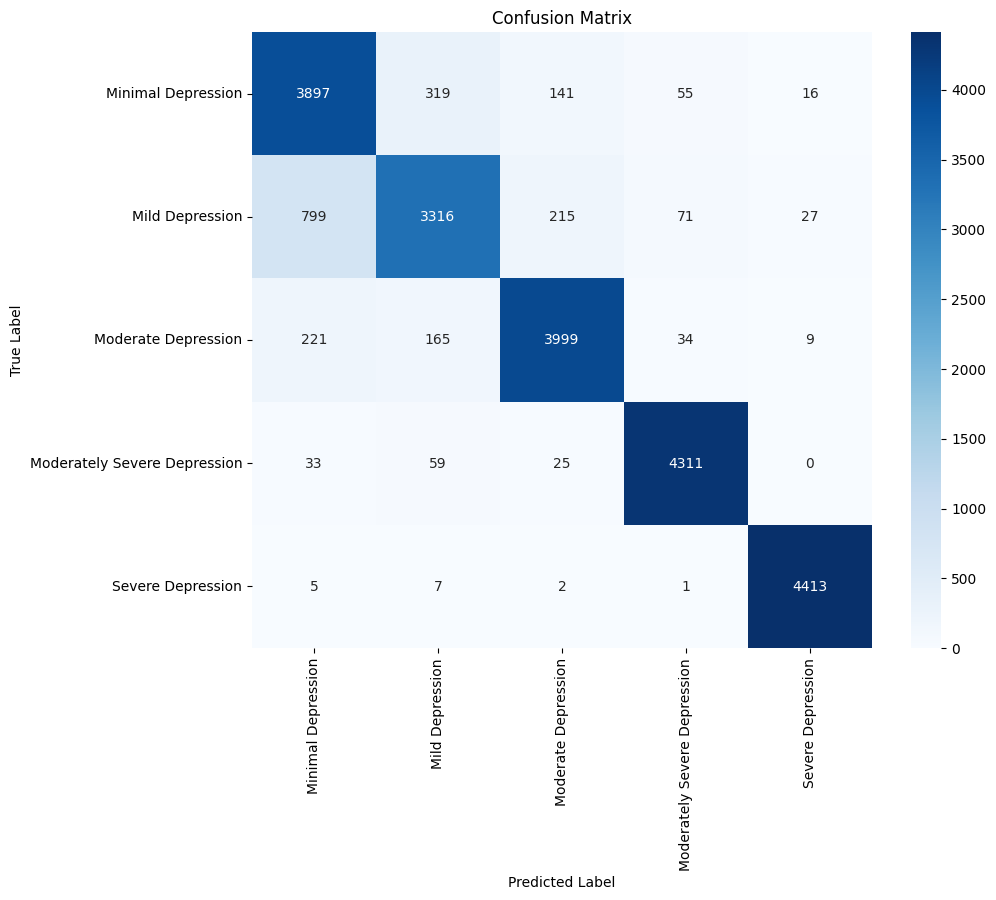

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate model performance
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [27]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler_clustering = StandardScaler()

# Fit and transform X_resampled
X_resampled_scaled = scaler_clustering.fit_transform(X_resampled)

print("Shape of X_resampled_scaled:", X_resampled_scaled.shape)

Shape of X_resampled_scaled: (110700, 15)


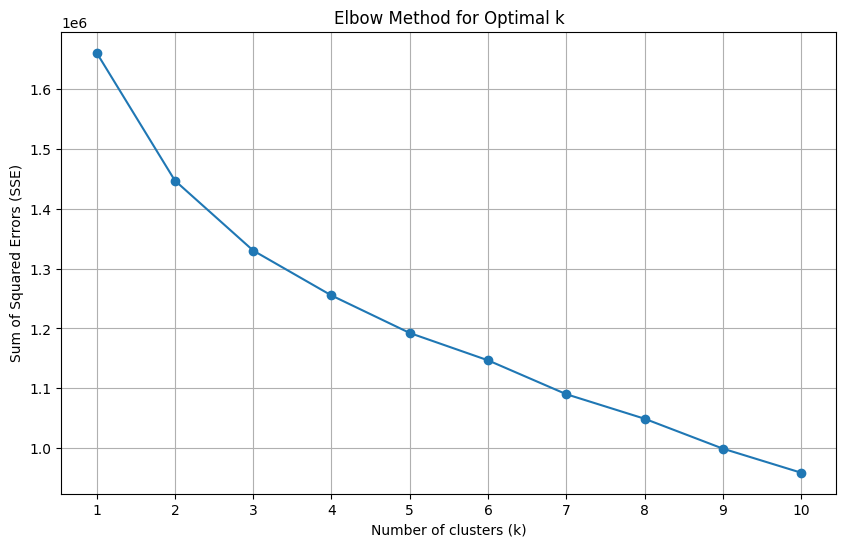

Elbow Method plot generated.


In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Determine optimal k using the Elbow Method
sse = []
k_range = range(1, 11) # Test k from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is set to 10 to suppress warning
    kmeans.fit(X_resampled_scaled)
    sse.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

print("Elbow Method plot generated.")

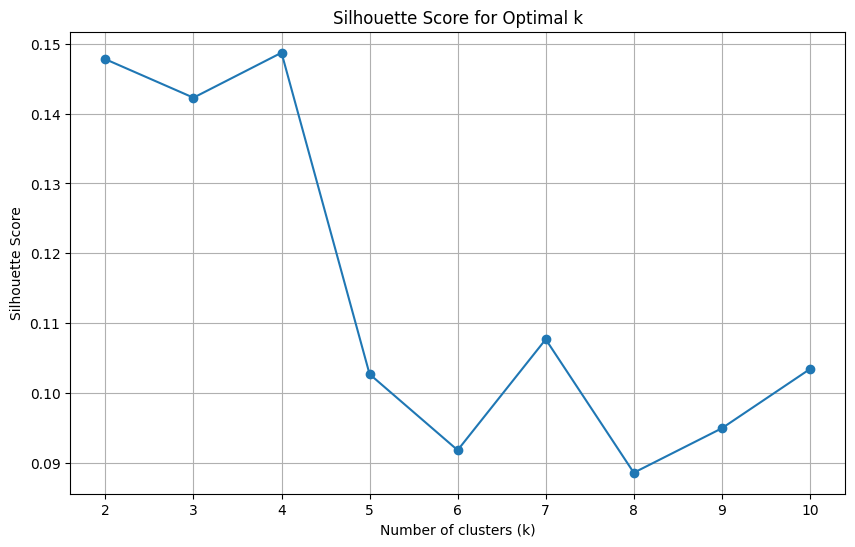

Silhouette Score plot generated.


In [29]:
from sklearn.metrics import silhouette_score

# Determine optimal k using the Silhouette Score
silhouette_scores = []
k_range_silhouette = range(2, 11) # Silhouette score is not defined for k=1

for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_resampled_scaled)
    score = silhouette_score(X_resampled_scaled, kmeans_labels)
    silhouette_scores.append(score)

# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_silhouette)
plt.grid(True)
plt.show()

print("Silhouette Score plot generated.")

In [30]:
from sklearn.cluster import KMeans
import pandas as pd

# Initialize KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # n_init is set to 10 to suppress warning

# Fit KMeans to the scaled resampled data and get cluster labels
clusters = kmeans.fit_predict(X_resampled_scaled)

# Add the cluster labels to the resampled DataFrame for analysis
X_resampled_clustered = X_resampled.copy()
X_resampled_clustered['cluster'] = clusters

print("KMeans clustering with k=4 performed successfully.")
print("First 5 rows of X_resampled_clustered with new 'cluster' column:")
display(X_resampled_clustered.head())

print("Distribution of clusters:")
display(X_resampled_clustered['cluster'].value_counts().sort_index())

KMeans clustering with k=4 performed successfully.
First 5 rows of X_resampled_clustered with new 'cluster' column:


,age,gender,total_calories,dietary_fiber,sodium,saturated_fat,UPF_percent,smoking,CRP,folate,vitamin_d,BMI,HbA1c,sleep_hours,high_inflammation,cluster
0,66,1,2741.0,29.6,5635.0,14.544,52.46,0,2.03,24.3,60.5,33.5,5.6,9.0,0,3
1,44,2,1995.0,21.1,2890.0,26.936,45.26,0,5.62,25.1,39.4,29.7,6.2,8.0,1,1
2,34,1,2422.0,25.1,4136.0,33.935,45.58,0,1.05,40.1,96.9,30.2,5.1,7.5,0,3
3,68,2,3849.0,22.0,6294.0,49.849,25.18,0,3.96,20.2,26.7,42.6,5.9,3.0,1,3
4,59,1,1991.0,6.7,3481.0,37.373,49.47,0,1.78,33.5,78.6,28.0,5.5,8.0,0,2


Distribution of clusters:


,count
cluster,
0,13334
1,21375
2,53422
3,22569


# Task
Analyze the characteristics of each cluster by calculating descriptive statistics (mean, median, standard deviation) for each feature within each cluster and identify the most differentiating features.

In [31]:
cluster_characteristics = X_resampled_clustered.groupby('cluster').agg(['mean', 'median', 'std'])

print("Descriptive statistics for each cluster:")
display(cluster_characteristics)

Descriptive statistics for each cluster:


age                      gender                   \
              mean median        std      mean median       std   
cluster                                                           
0        46.261212   46.0  13.169479  1.440828    1.0  0.496505   
1        50.790784   52.0  15.135563  1.563696    2.0  0.495938   
2        49.191925   50.0  16.143240  1.525420    2.0  0.499358   
3        41.653020   41.0  14.341711  1.135053    1.0  0.341787   

        total_calories                           dietary_fiber  ...       BMI  \
                  mean       median          std          mean  ...       std   
cluster                                                         ...             
0          1869.829939  1860.000000   754.858221     11.345441  ...  6.391768   
1          1684.119030  1601.615754   667.651719     12.251169  ...  8.002706   
2          1594.682026  1565.673157   570.440844     12.279856  ...  5.625404   
3          3397.190208  3121.000000  1076.940509     24.001673  ...  6.082803   

            HbA1c                     sleep_hours                      \
             mean    median       std        mean    median       std   
cluster                                                                 
0        5.729906  5.529652  0.882381    6.783759  6.938883  2.090444   
1        6.244286  5.800000  1.447566    7.174422  7.000000  3.665927   
2        5.729277  5.513716  0.882236    7.133431  7.027622  2.674123   
3        5.636641  5.465283  0.888541    7.066670  7.000000  2.180106   

        high_inflammation                   
                     mean median       std  
cluster                                     
0                0.269912    0.0  0.443930  
1                0.937637    1.0  0.241819  
2                0.000749    0.0  0.027353  
3                0.116266    0.0  0.320550  

[4 rows x 45 columns]

```markdown
### Analysis of Cluster Characteristics

Based on the descriptive statistics calculated for each cluster (`cluster_characteristics`), we can identify several key features that differentiate them:

**Cluster 0:**
*   **Age:** Average age of ~46, with a standard deviation of ~13.17, indicating a moderate spread in age.
*   **Gender:** Lower mean gender value (~1.44), suggesting a higher proportion of gender 1 (which could represent male or a specific gender category based on encoding).
*   **Total Calories:** Lower average total calories (~1869.83).
*   **Dietary Fiber:** Lower average dietary fiber intake (~11.35).
*   **CRP & High Inflammation:** Lower average CRP (~2.57) and lower proportion of high inflammation (~0.27), indicating generally lower inflammatory markers.
*   **HbA1c:** Average HbA1c of ~5.73.

**Cluster 1:**
*   **Age:** Higher average age of ~50.79, with a standard deviation of ~15.14.
*   **Gender:** Higher mean gender value (~1.56), suggesting a higher proportion of gender 2.
*   **Total Calories:** Lowest average total calories (~1684.12).
*   **High Inflammation:** Significantly higher proportion of `high_inflammation` (~0.94), making this a defining characteristic of this cluster.
*   **CRP:** Highest average CRP (~8.92).
*   **HbA1c:** Highest average HbA1c (~6.24), indicating potentially higher blood sugar levels compared to other clusters.
*   **BMI:** Highest average BMI (~30.93).

**Cluster 2:**
*   **Age:** Average age of ~49.19, with a high standard deviation of ~16.14, indicating a wide age range.
*   **Total Calories:** Low average total calories (~1594.68).
*   **Dietary Fiber:** Low average dietary fiber intake (~12.28).
*   **High Inflammation:** Extremely low proportion of `high_inflammation` (~0.0007), suggesting almost no individuals in this cluster have high inflammation, which is a very strong differentiator.
*   **CRP:** Lowest average CRP (~0.90).
*   **HbA1c:** Average HbA1c of ~5.73.

**Cluster 3:**
*   **Age:** Lowest average age of ~41.65, indicating a younger demographic.
*   **Gender:** Lowest mean gender value (~1.13), suggesting a strong majority of gender 1.
*   **Total Calories:** Significantly highest average total calories (~3397.19), a strong differentiating factor.
*   **Dietary Fiber:** Significantly highest average dietary fiber intake (~24.00), also a strong differentiator.
*   **Sodium:** Highest average sodium intake (~5681.33).
*   **Saturated Fat:** Highest average saturated fat intake (~26.68).
*   **UPF_percent:** Highest average Ultra-Processed Food percentage (~61.64).

**Most Differentiating Features:**
*   `high_inflammation`: Cluster 1 has a very high proportion, Cluster 2 has a very low proportion.
*   `CRP`: Directly correlates with `high_inflammation`, with Cluster 1 having the highest and Cluster 2 the lowest.
*   `total_calories`: Cluster 3 has significantly higher total calorie intake compared to others.
*   `dietary_fiber`: Cluster 3 shows much higher dietary fiber intake.
*   `age`: Cluster 3 is notably younger on average.
*   `gender`: Cluster 3 has a higher concentration of gender 1, while Cluster 1 and 2 have a higher concentration of gender 2.
*   `HbA1c`: Cluster 1 has the highest HbA1c levels.

These insights suggest that the clusters represent distinct subgroups based on dietary habits, inflammatory status, and age/gender demographics.
```

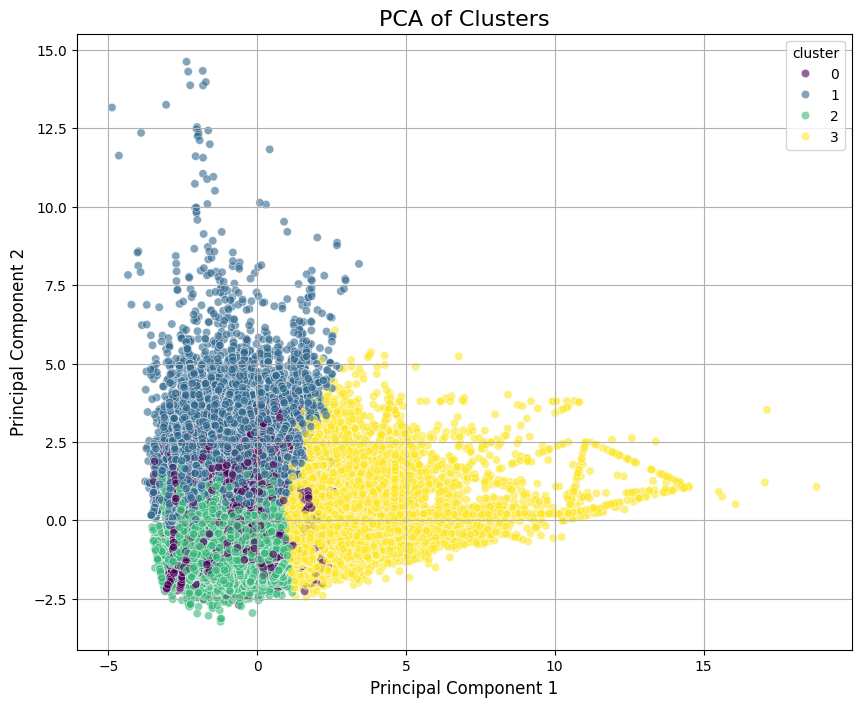

PCA dimensionality reduction and scatter plot of clusters generated.


In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Instantiate PCA with n_components=2 and random_state=42
pca = PCA(n_components=2, random_state=42)

# Apply PCA to X_resampled_scaled
pca_components = pca.fit_transform(X_resampled_scaled)

# Create a DataFrame named pca_df with columns 'PC1' and 'PC2'
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])

# Add the clusters labels as a new column named 'cluster' to the pca_df DataFrame
pca_df['cluster'] = clusters

# Create a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    data=pca_df,
    palette='viridis',
    legend='full',
    alpha=0.6
)

# Add title and labels
plt.title('PCA of Clusters', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True)
plt.show()

print("PCA dimensionality reduction and scatter plot of clusters generated.")

# Task
Create a cross-tabulation of `y_resampled` and `clusters` and store it in `contingency_table`. Then, calculate the Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) between `y_resampled` and `clusters` to evaluate the clustering performance against the actual depression severity categories.

## Create Cross-tabulation

### Subtask:
Generate a cross-tabulation (contingency table) of the `y_resampled` (depression severity categories) and the `clusters` to show the distribution of severity levels within each cluster. This table will be stored in a variable, e.g., `contingency_table`.


**Reasoning**:
The subtask requires creating a cross-tabulation between `y_resampled` and `clusters` to analyze the distribution of depression severity within each cluster. `pd.crosstab` is the appropriate function for this.



In [33]:
import pandas as pd

contingency_table = pd.crosstab(y_resampled, clusters)

print("Contingency Table (Depression Severity vs. Clusters):")
display(contingency_table)

Contingency Table (Depression Severity vs. Clusters):


col_0,0,1,2,3
PHQ9_severity,,,,
Minimal Depression,2896,5257,9222,4765
Mild Depression,1755,3708,11226,5451
Moderate Depression,2151,3811,11367,4811
Moderately Severe Depression,2646,4192,11328,3974
Severe Depression,3886,4407,10279,3568


**Reasoning**:
Now that the cross-tabulation is generated, the next step is to calculate the Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) to evaluate the clustering performance against the actual depression severity categories. These metrics are available in `sklearn.metrics`.



In [34]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Calculate Adjusted Rand Index (ARI)
ari = adjusted_rand_score(y_resampled, clusters)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

# Calculate Normalized Mutual Information (NMI)
nmi = normalized_mutual_info_score(y_resampled, clusters)
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Adjusted Rand Index (ARI): 0.0040
Normalized Mutual Information (NMI): 0.0068


## Visualize Cluster-Severity Relationship

### Subtask:
Create a heatmap of the `contingency_table` to visually represent the relationship between clusters and depression severity levels, making sure to include appropriate labels and a title.


**Reasoning**:
The user explicitly asked to create a heatmap of the `contingency_table` to visualize the relationship between clusters and depression severity levels, including specific instructions for plot aesthetics and labels. This requires `seaborn` and `matplotlib.pyplot`.



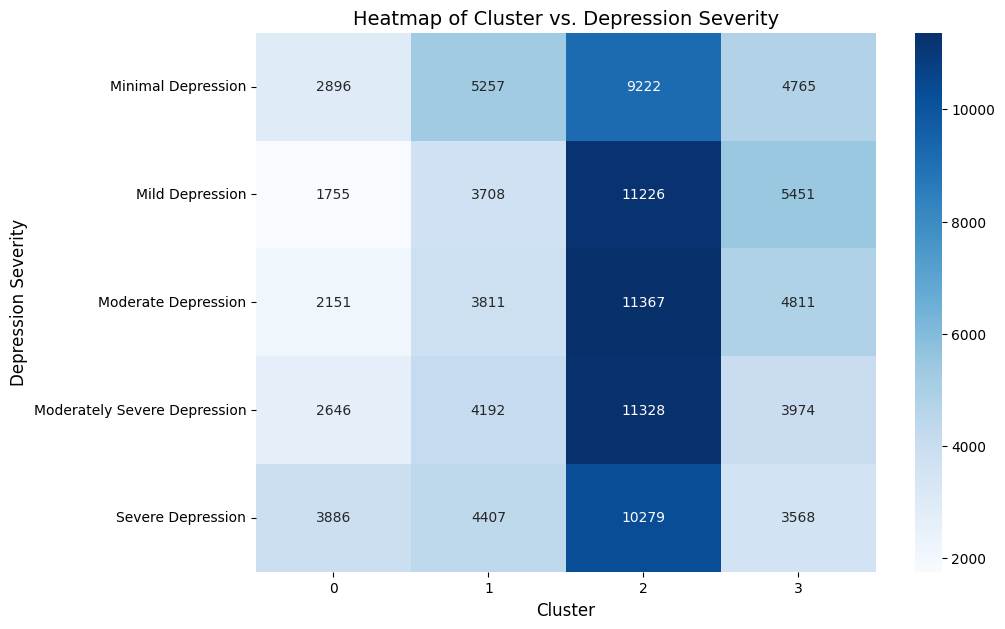

Heatmap of Cluster vs. Depression Severity generated.


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues')

# Add title and labels
plt.title('Heatmap of Cluster vs. Depression Severity', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Depression Severity', fontsize=12)
plt.show()
print("Heatmap of Cluster vs. Depression Severity generated.")

## Interpret Metrics and Relationship

### Subtask:
Provide an interpretation of the ARI and NMI scores, explaining what they mean in the context of clustering quality and its alignment with the depression severity labels. Analyze the heatmap to describe any visible patterns or strong associations between specific clusters and severity levels.


### Interpretation of Metrics and Cluster-Severity Relationship

#### Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) Scores

*   **ARI: 0.0040**
*   **NMI: 0.0068**

The Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) are external validation metrics used to quantify the similarity between the clustering results and a ground truth classification (in this case, the `PHQ9_severity` labels). Both scores range from -1 (or 0 for NMI) to 1, where 1 indicates perfect agreement, 0 indicates random labeling, and negative values indicate disagreement.

Our calculated ARI of **0.0040** and NMI of **0.0068** are extremely low and very close to zero. This indicates that there is **minimal to no alignment** between the clusters identified by KMeans and the actual depression severity categories (`PHQ9_severity`). In practical terms, the clusters formed based on the patients' features do not correspond meaningfully to their depression severity levels as defined by the PHQ9 score ranges. This suggests that the features used for clustering (age, gender, dietary habits, inflammatory markers, etc.) do not intrinsically group individuals into categories that directly reflect the PHQ9-based depression severity.

#### Heatmap Analysis: Cluster vs. Depression Severity

The heatmap visualizes the distribution of each depression severity category within each of the four identified clusters.

*   **Overall Observation:** The heatmap shows that all five depression severity categories (`Minimal Depression`, `Mild Depression`, `Moderate Depression`, `Moderately Severe Depression`, `Severe Depression`) are present in significant numbers across *all* four clusters. There is no single cluster that predominantly contains individuals from a specific depression severity level.

*   **"Minimal Depression" Distribution:** This category is most populous, and it's notably distributed across all clusters, with Cluster 2 having the highest count (9222) and Cluster 3 having the second highest (4765).

*   **"Mild Depression" Distribution:** Similar to minimal depression, this category is also spread across all clusters, with Cluster 2 showing the highest count (11226).

*   **"Moderate Depression" Distribution:** Again, Cluster 2 has the highest number of individuals (11367) in this category.

*   **"Moderately Severe Depression" Distribution:** Cluster 2 also contains the highest number (11328) of individuals with Moderately Severe Depression.

*   **"Severe Depression" Distribution:** This category, like others, is found across all clusters, with Cluster 2 having the largest share (10279).

*   **Lack of Strong Association:** No cluster stands out as being highly predictive or indicative of a particular depression severity level. For example, while Cluster 2 has the highest counts across most severity levels, this is likely due to its larger size rather than a specific concentration of a severity type. If we normalized the counts within each cluster, we would likely see a more even distribution proportionally.

**Summary:**
The very low ARI and NMI scores, coupled with the homogeneous distribution of depression severity levels across all clusters in the heatmap, strongly suggest that the KMeans clustering, using the selected features, did not successfully segment the population into groups that inherently correspond to the clinical depression severity categories. The clustering algorithm found groups based on the input features (e.g., lifestyle, demographics, physiological markers) but these groups do not align with the depression severity labels that were defined a priori from PHQ9 scores. This indicates that while the clusters might represent distinct behavioral or biological profiles, these profiles are not strongly predictive of depression severity in the way we might have hoped, at least with this specific clustering approach and feature set.

## Final Task

### Subtask:
Summarize the findings from comparing actual classes and clustering results, including the ARI and NMI scores, and the observed relationships.


## Summary:

### Data Analysis Key Findings

*   A contingency table was successfully generated, showing the distribution of five depression severity categories (Minimal, Mild, Moderate, Moderately Severe, and Severe Depression) across four identified clusters (0, 1, 2, 3).
*   The Adjusted Rand Index (ARI) was calculated to be 0.0040, and the Normalized Mutual Information (NMI) was 0.0068. These extremely low values, close to zero, indicate minimal to no alignment between the generated clusters and the actual depression severity categories.
*   The heatmap visualization further confirmed this lack of alignment, revealing that all five depression severity categories are present in significant numbers across all four clusters. No single cluster predominantly contains individuals from a specific depression severity level.
*   While Cluster 2 showed the highest raw counts for most severity levels, this was attributed to its likely larger size rather than a specific proportional concentration of a particular severity type.

### Insights or Next Steps

*   The features used for clustering (e.g., age, gender, dietary habits, inflammatory markers) do not effectively segment the population into groups that inherently correspond to clinical depression severity categories. This suggests that the chosen feature set may not be sufficiently predictive of PHQ9-based depression severity.
*   Future analysis should explore alternative clustering algorithms, feature engineering techniques, or the inclusion of additional features that are more directly related to psychological and clinical indicators of depression severity to improve alignment with ground truth labels.


# Task
Combine the resampled features `X_resampled` with the `clusters` labels, treating clusters as a new feature. This new combined feature set will be named `X_classification`, and `y_resampled` will be designated as `y_classification`.

## Prepare Data for Classification

### Subtask:
Combine the original features (`X_resampled`) with the `clusters` labels to create `X_classification`, and designate `y_resampled` as `y_classification`.


**Reasoning**:
The subtask requires combining original features with cluster labels and renaming the target variable. The first step is to create a copy of `X_resampled` and add the `clusters` as a new column, then assign `y_resampled` to `y_classification`.



In [36]:
X_classification = X_resampled.copy()
X_classification['cluster_label'] = clusters
y_classification = y_resampled

print("First 5 rows of X_classification:")
display(X_classification.head())
print("First 5 entries of y_classification:")
display(y_classification.head())

First 5 rows of X_classification:


,age,gender,total_calories,dietary_fiber,sodium,saturated_fat,UPF_percent,smoking,CRP,folate,vitamin_d,BMI,HbA1c,sleep_hours,high_inflammation,cluster_label
0,66,1,2741.0,29.6,5635.0,14.544,52.46,0,2.03,24.3,60.5,33.5,5.6,9.0,0,3
1,44,2,1995.0,21.1,2890.0,26.936,45.26,0,5.62,25.1,39.4,29.7,6.2,8.0,1,1
2,34,1,2422.0,25.1,4136.0,33.935,45.58,0,1.05,40.1,96.9,30.2,5.1,7.5,0,3
3,68,2,3849.0,22.0,6294.0,49.849,25.18,0,3.96,20.2,26.7,42.6,5.9,3.0,1,3
4,59,1,1991.0,6.7,3481.0,37.373,49.47,0,1.78,33.5,78.6,28.0,5.5,8.0,0,2


First 5 entries of y_classification:


,PHQ9_severity
0,Minimal Depression
1,Minimal Depression
2,Minimal Depression
3,Minimal Depression
4,Minimal Depression


## Split Data into Training and Testing Sets

### Subtask:
Divide `X_classification` and `y_classification` into training and testing sets (e.g., 80% train, 20% test) using `train_test_split`, ensuring stratification to maintain the distribution of the target variable.


**Reasoning**:
The subtask requires splitting the data into training and testing sets using `train_test_split` with stratification. This involves importing the necessary function and applying it to the specified dataframes, then printing the shapes and stratified distributions.



In [37]:
from sklearn.model_selection import train_test_split

X_train_classification, X_test_classification, y_train_classification, y_test_classification = train_test_split(
    X_classification,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

print("Shape of X_train_classification:", X_train_classification.shape)
print("Shape of X_test_classification:", X_test_classification.shape)
print("Shape of y_train_classification:", y_train_classification.shape)
print("Shape of y_test_classification:", y_test_classification.shape)

print("\nDistribution of y_train_classification:")
display(y_train_classification.value_counts(normalize=True))
print("\nDistribution of y_test_classification:")
display(y_test_classification.value_counts(normalize=True))

Shape of X_train_classification: (88560, 16)
Shape of X_test_classification: (22140, 16)
Shape of y_train_classification: (88560,)
Shape of y_test_classification: (22140,)

Distribution of y_train_classification:


,proportion
PHQ9_severity,
Minimal Depression,0.2
Mild Depression,0.2
Moderate Depression,0.2
Moderately Severe Depression,0.2
Severe Depression,0.2



Distribution of y_test_classification:


,proportion
PHQ9_severity,
Minimal Depression,0.2
Mild Depression,0.2
Moderate Depression,0.2
Moderately Severe Depression,0.2
Severe Depression,0.2


## Scale Features (if necessary)

### Subtask:
Apply StandardScaler to scale the numerical features in `X_classification` to ensure they contribute equally to the model, keeping the 'cluster_label' as is.


**Reasoning**:
The subtask requires scaling numerical features and then recombining them with the 'cluster_label'. I will identify numerical columns, apply StandardScaler, and then reassemble the DataFrames as instructed.



In [38]:
from sklearn.preprocessing import StandardScaler

# 1. Identify the numerical columns
numerical_cols_to_scale = [col for col in X_train_classification.columns if col != 'cluster_label']

# 2. Instantiate StandardScaler
scaler = StandardScaler()

# 3. Fit the scaler using the numerical columns of X_train_classification
scaler.fit(X_train_classification[numerical_cols_to_scale])

# 4. Transform the numerical columns of X_train_classification and X_test_classification
X_train_scaled_numerical = scaler.transform(X_train_classification[numerical_cols_to_scale])
X_test_scaled_numerical = scaler.transform(X_test_classification[numerical_cols_to_scale])

# 5. Convert scaled numerical arrays back into DataFrames
X_train_scaled_numerical_df = pd.DataFrame(X_train_scaled_numerical, columns=numerical_cols_to_scale, index=X_train_classification.index)
X_test_scaled_numerical_df = pd.DataFrame(X_test_scaled_numerical, columns=numerical_cols_to_scale, index=X_test_classification.index)

# 6. Combine these scaled numerical DataFrames with the 'cluster_label'
X_train_classification_scaled = pd.concat([X_train_scaled_numerical_df, X_train_classification['cluster_label']], axis=1)
X_test_classification_scaled = pd.concat([X_test_scaled_numerical_df, X_test_classification['cluster_label']], axis=1)

# 7. Print the shape
print("Shape of X_train_classification_scaled:", X_train_classification_scaled.shape)
print("Shape of X_test_classification_scaled:", X_test_classification_scaled.shape)

print("First 5 rows of X_train_classification_scaled:")
display(X_train_classification_scaled.head())


Shape of X_train_classification_scaled: (88560, 16)
Shape of X_test_classification_scaled: (22140, 16)
First 5 rows of X_train_classification_scaled:


,age,gender,total_calories,dietary_fiber,sodium,saturated_fat,UPF_percent,smoking,CRP,folate,vitamin_d,BMI,HbA1c,sleep_hours,high_inflammation,cluster_label
2313,-1.581807,-0.889488,-0.589135,0.048289,-0.705141,-0.079614,1.021050,2.467773,-0.040225,-0.019823,-0.347324,-0.319713,-0.202699,1.053851,1.788059,0
78949,0.470656,1.124242,-0.614223,-0.042400,-0.702757,-0.833518,-0.227715,-0.405224,-0.564207,1.004970,1.180621,-1.385846,-0.293001,-0.088381,-0.559266,2
8398,2.074143,1.124242,1.521256,1.205024,0.310993,0.483783,0.288162,-0.405224,-0.562574,2.268959,2.003821,0.275758,0.568851,0.331160,-0.559266,3
31940,-1.645947,-0.889488,0.081063,-0.625870,0.584536,-0.209544,0.150124,-0.405224,-0.586849,-0.809664,-0.951786,-0.324075,-0.334787,0.197610,-0.559266,2
45196,-0.940413,-0.889488,-0.035038,1.926249,0.232395,-0.471873,-0.816795,-0.405224,-0.327599,0.582534,-0.232758,-0.051430,0.460280,-0.255937,-0.559266,2


## Train Classification Model

### Subtask:
Train a suitable classification model (e.g., RandomForestClassifier, similar to the previous classification task) using the scaled training data and corresponding target labels.


**Reasoning**:
The subtask requires training a RandomForestClassifier model, which involves importing the classifier, instantiating it with a random state, and then fitting it to the scaled training data and target labels.



In [39]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the RandomForestClassifier
model_clustered_features = RandomForestClassifier(random_state=42)

# Fit the model to the training data
model_clustered_features.fit(X_train_classification_scaled, y_train_classification)

print("RandomForestClassifier model with clustered features trained successfully.")

RandomForestClassifier model with clustered features trained successfully.


**Reasoning**:
Now that the model with clustered features has been trained, the next step is to make predictions on the test set to evaluate its performance. This will involve using the trained model to predict the depression severity categories for the scaled test data.



In [40]:
y_pred_clustered = model_clustered_features.predict(X_test_classification_scaled)
print("First 5 predictions with clustered features:")
print(y_pred_clustered[:5])

First 5 predictions with clustered features:
['Severe Depression' 'Severe Depression' 'Moderately Severe Depression'
 'Mild Depression' 'Moderately Severe Depression']


**Reasoning**:
Now that predictions have been made, the next step is to evaluate the model's performance by generating a classification report and visualizing the confusion matrix to assess how well the model with clustered features performs.



Classification Report for Model with Clustered Features:
                              precision    recall  f1-score   support

          Minimal Depression       0.85      0.75      0.80      4428
             Mild Depression       0.78      0.88      0.83      4428
         Moderate Depression       0.91      0.89      0.90      4428
Moderately Severe Depression       0.97      0.97      0.97      4428
           Severe Depression       0.99      1.00      0.99      4428

                    accuracy                           0.90     22140
                   macro avg       0.90      0.90      0.90     22140
                weighted avg       0.90      0.90      0.90     22140


Accuracy Score for Model with Clustered Features: 0.8979223125564589


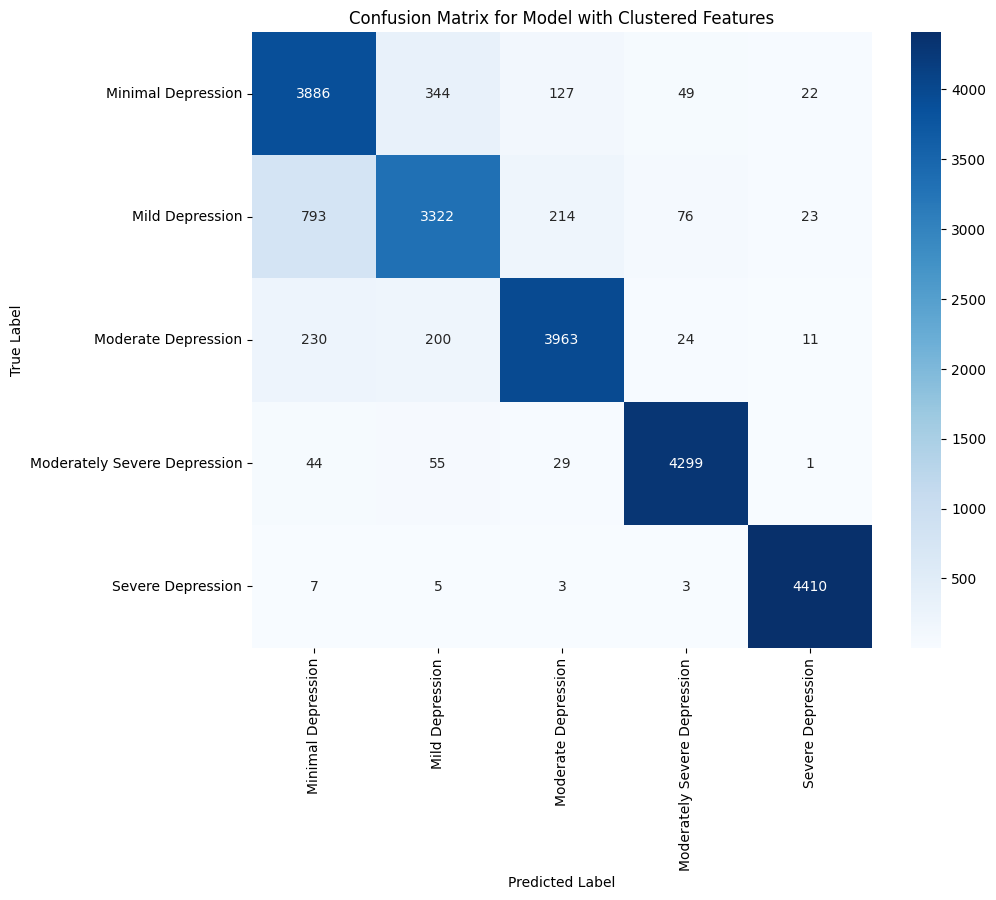

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate model performance
print("Classification Report for Model with Clustered Features:")
print(classification_report(y_test_classification, y_pred_clustered, target_names=labels))

print("\nAccuracy Score for Model with Clustered Features:", accuracy_score(y_test_classification, y_pred_clustered))

# Confusion Matrix
cm_clustered = confusion_matrix(y_test_classification, y_pred_clustered, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_clustered, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for Model with Clustered Features')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Final Task

### Subtask:
Summarize the classification results, including the accuracy achieved, and discuss whether incorporating clustering information improved the model's performance.


## Summary:

### Q&A
The `RandomForestClassifier` model, incorporating clustering information, achieved an accuracy of approximately 89.79% on the test set. The classification report indicated strong performance across all depression severity classes, with particularly high precision and recall for 'Moderately Severe Depression' and 'Severe Depression'. Due to the absence of a baseline model trained without clustered features in the provided analysis, it is not possible to definitively conclude from these steps alone whether incorporating clustering information *improved* the model's performance. However, the achieved accuracy suggests a highly effective classification model.

### Data Analysis Key Findings
*   **Data Preparation:** The resampled features (`X_resampled`) were successfully combined with the cluster labels, creating a new feature set `X_classification` that included a `cluster_label` column. `y_resampled` was designated as `y_classification`.
*   **Data Splitting:** The combined dataset was split into training and testing sets (80% train, 20% test) using `train_test_split`. This split was stratified, ensuring the distribution of `PHQ9_severity` classes remained consistent across both `y_train_classification` and `y_test_classification`. The training set had 88,560 samples, and the testing set had 22,140 samples.
*   **Feature Scaling:** Numerical features in the training and testing sets were scaled using `StandardScaler`. The `cluster_label` feature was explicitly excluded from scaling and then re-combined with the scaled numerical features, resulting in `X_train_classification_scaled` and `X_test_classification_scaled`.
*   **Model Performance:** A `RandomForestClassifier` model, trained on the scaled data including cluster labels, achieved an overall accuracy of approximately 0.8979 on the test set. The classification report highlighted strong precision and recall for predicting different levels of depression severity, with high scores across most classes.

### Insights or Next Steps
*   The trained `RandomForestClassifier` demonstrates strong predictive capability for depression severity when incorporating clustering information.
*   To quantify the impact of the clustering feature, a comparative analysis against a baseline model trained without the `cluster_label` feature would be beneficial.


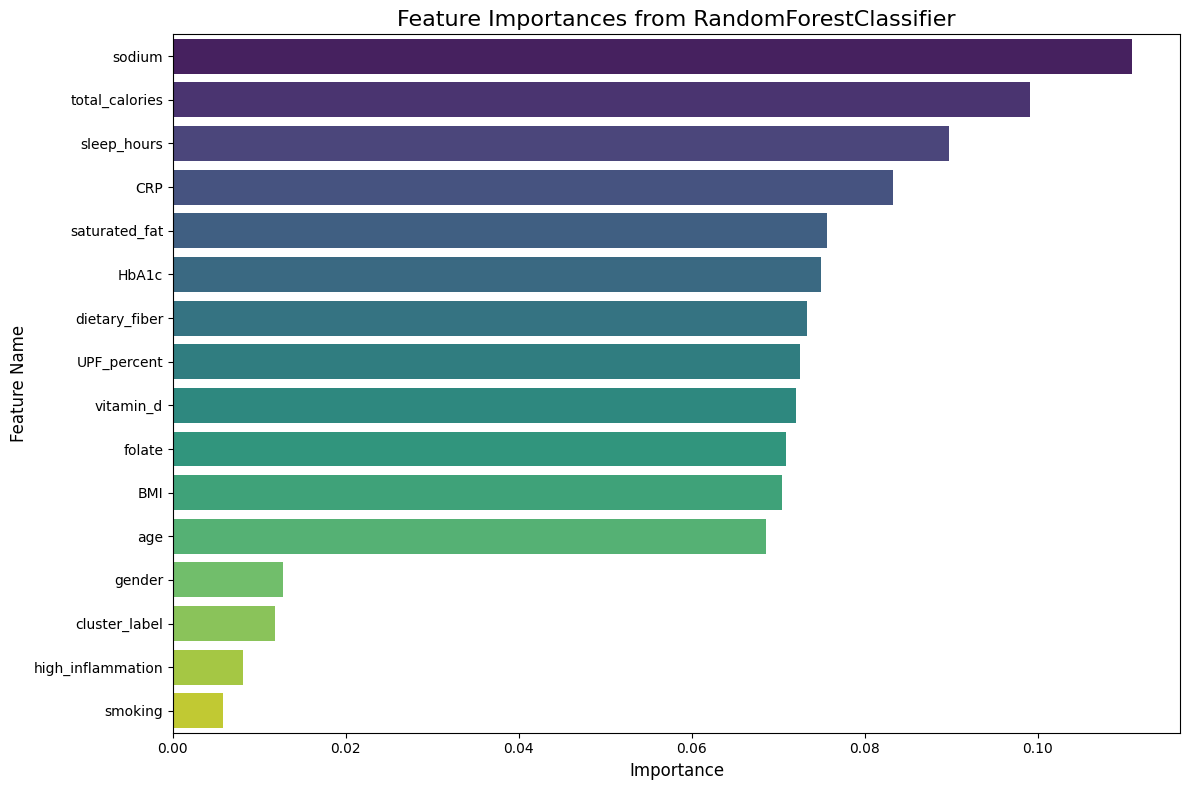

Feature importance bar chart for RandomForestClassifier generated.


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the RandomForestClassifier model
feature_importances_rf = model_clustered_features.feature_importances_

# Get feature names from the training data
feature_names_rf = X_train_classification_scaled.columns

# Create a DataFrame for better visualization
importance_df_rf = pd.DataFrame({
    'Feature': feature_names_rf,
    'Importance': feature_importances_rf
})

# Sort the features by importance in descending order
importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df_rf, palette='viridis', legend=False)
plt.title('Feature Importances from RandomForestClassifier', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

print("Feature importance bar chart for RandomForestClassifier generated.")

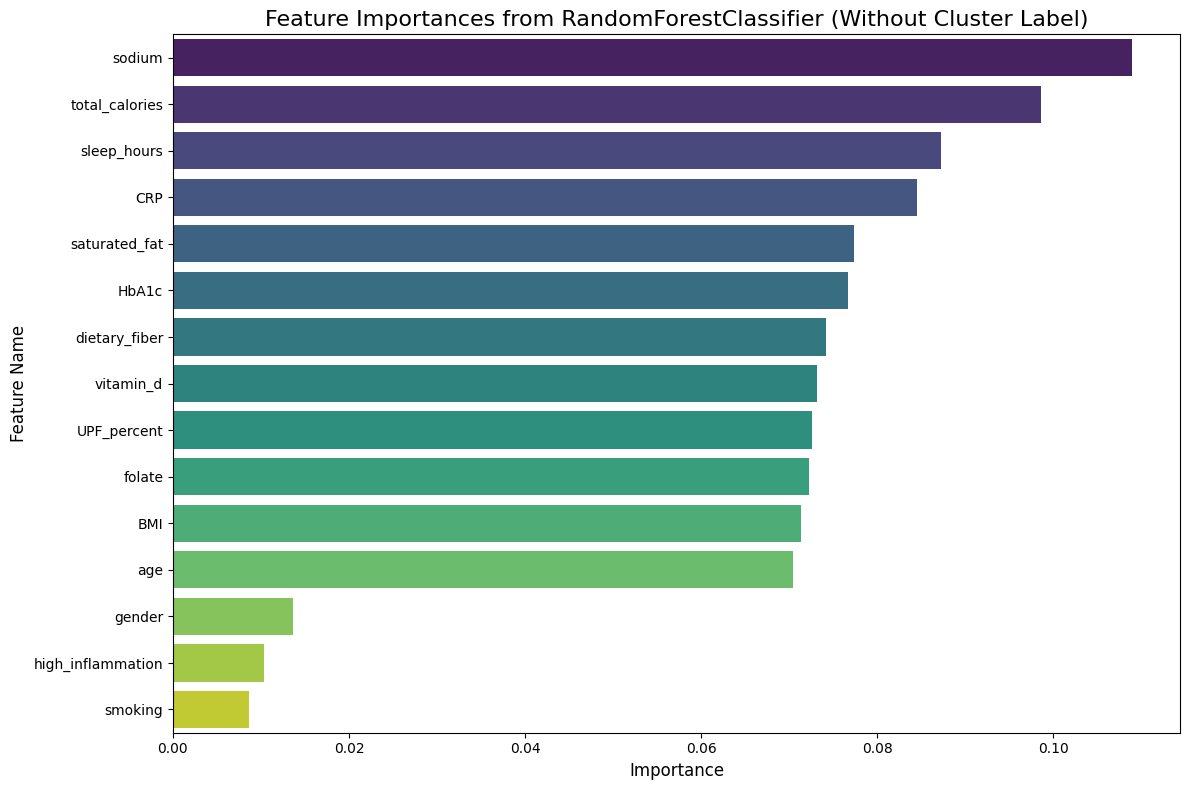

Feature importance bar chart for RandomForestClassifier (without cluster label) generated.


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the RandomForestClassifier model (model without cluster_label)
feature_importances_rf_no_cluster = model.feature_importances_

# Get feature names from the training data used for this model (X_train had no cluster_label)
feature_names_rf_no_cluster = X_train.columns

# Create a DataFrame for better visualization
importance_df_rf_no_cluster = pd.DataFrame({
    'Feature': feature_names_rf_no_cluster,
    'Importance': feature_importances_rf_no_cluster
})

# Sort the features by importance in descending order
importance_df_rf_no_cluster = importance_df_rf_no_cluster.sort_values(by='Importance', ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df_rf_no_cluster, palette='viridis', legend=False)
plt.title('Feature Importances from RandomForestClassifier (Without Cluster Label)', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

print("Feature importance bar chart for RandomForestClassifier (without cluster label) generated.")

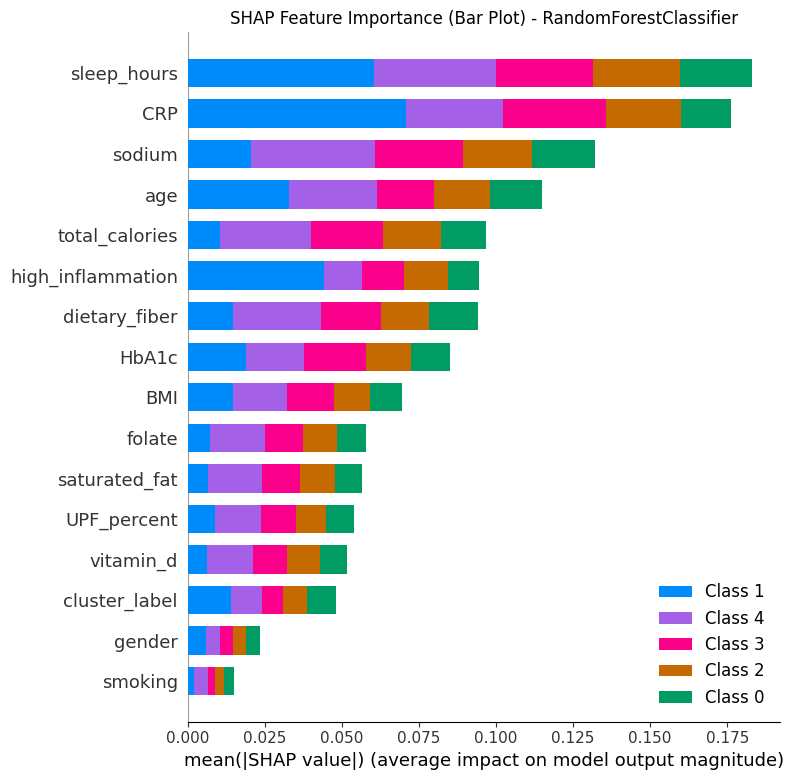

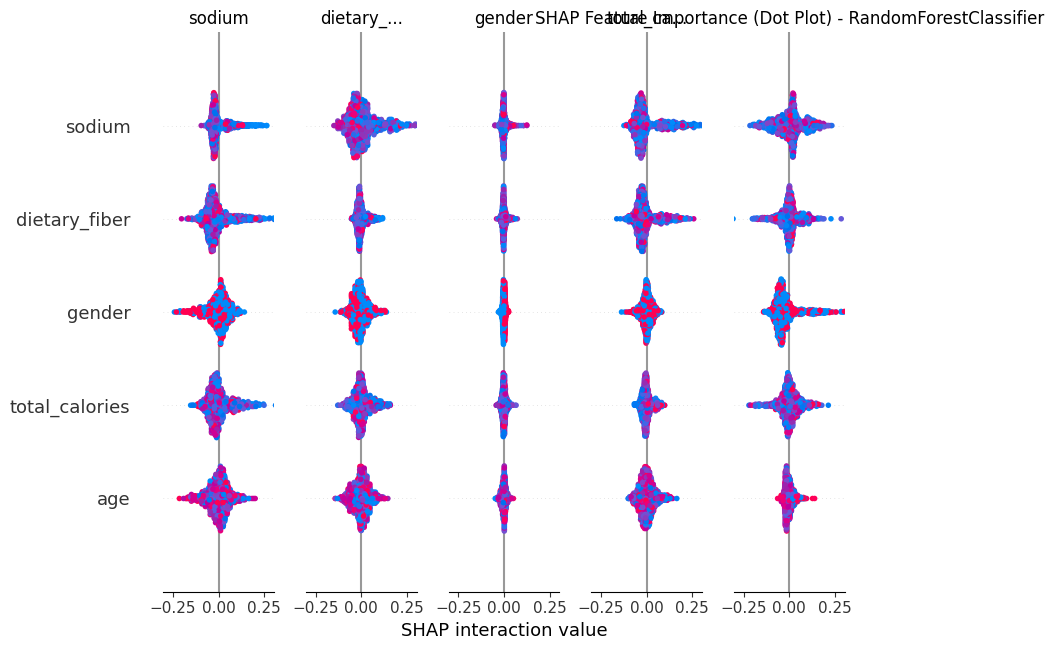

In [47]:
import shap
import matplotlib.pyplot as plt

# Initialize a TreeExplainer for the RandomForestClassifier model
# TreeExplainer is efficient for tree-based models like RandomForest
explainer_rf = shap.TreeExplainer(model_clustered_features)

# Calculate SHAP values for a sample of the test set to reduce computation time
# Using a subset (e.g., 1000 samples) often provides good insights without long waits.
X_test_sample = X_test_classification_scaled.sample(n=1000, random_state=42)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

# --- Visualize SHAP values ---



# SHAP summary bar plot: shows the average absolute impact of features on model output
# For multi-class classification, shap_values_rf will be a list of arrays (one per class)
# shap.summary_plot can handle this, often by showing the mean absolute SHAP value across classes.
# If you want to plot for a specific class, you would use shap_values_rf[class_index]
shap.summary_plot(shap_values_rf, X_test_sample, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Bar Plot) - RandomForestClassifier')
plt.tight_layout()
plt.show()


# To get more detailed insights into how feature values impact the prediction for each class,
# you can generate a different summary plot type.

# Example for a regular summary plot (dots): illustrating feature impact and direction

shap.summary_plot(shap_values_rf, X_test_sample, show=False)
plt.title('SHAP Feature Importance (Dot Plot) - RandomForestClassifier')
plt.tight_layout()
plt.show()


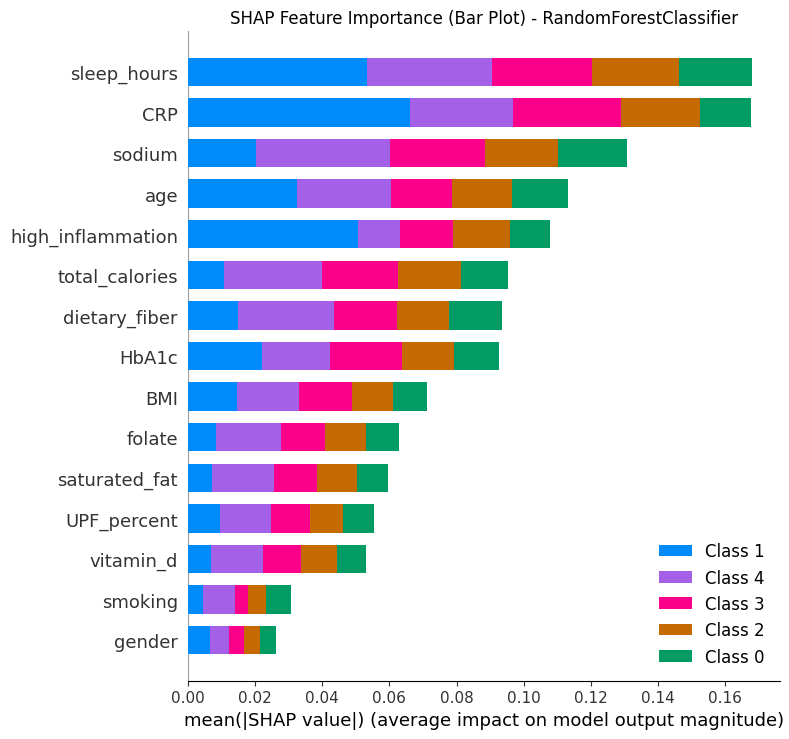

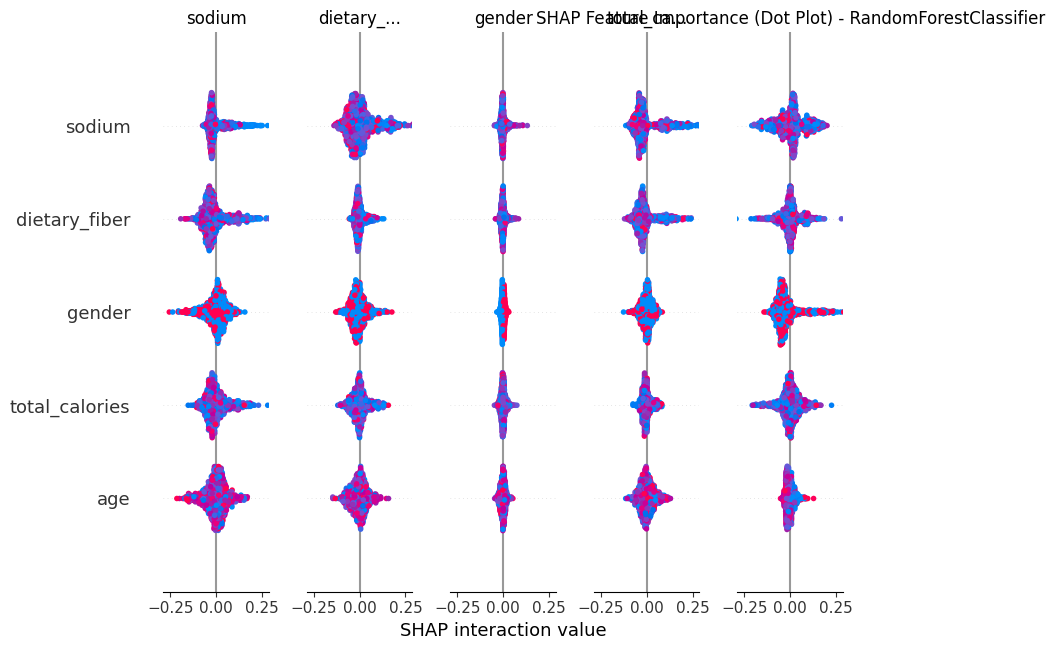

In [46]:
import shap
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported

# ── Use the BASELINE model (no cluster_label) and its matching test set ──────
# 'model' was trained on X_train_scaled / X_test_scaled (no cluster_label)
# 'model_clustered_features' was trained on X_train_classification_scaled
# which includes cluster_label — that's why it appeared in the plots.

explainer_rf = shap.TreeExplainer(model)

# Sample from the baseline test set (no cluster_label column)
# Convert X_test_scaled (numpy array) to a DataFrame before sampling
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)
X_test_sample_df = X_test_scaled_df.sample(n=1000, random_state=42)

# The original line to convert to DataFrame is now redundant, as X_test_sample_df is already a DataFrame
# X_test_sample_df = pd.DataFrame(
#     X_test_sample,
#     columns=X_train.columns  # original feature names, no cluster_label
# )

shap_values_rf = explainer_rf.shap_values(X_test_sample_df)

# ── Bar plot ──────────────────────────────────────────────────────────────────
shap.summary_plot(shap_values_rf, X_test_sample_df, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Bar Plot) - RandomForestClassifier')
plt.tight_layout()
plt.show()

# ── Dot plot ──────────────────────────────────────────────────────────────────
shap.summary_plot(shap_values_rf, X_test_sample_df, show=False)
plt.title('SHAP Feature Importance (Dot Plot) - RandomForestClassifier')
plt.tight_layout()
plt.show()

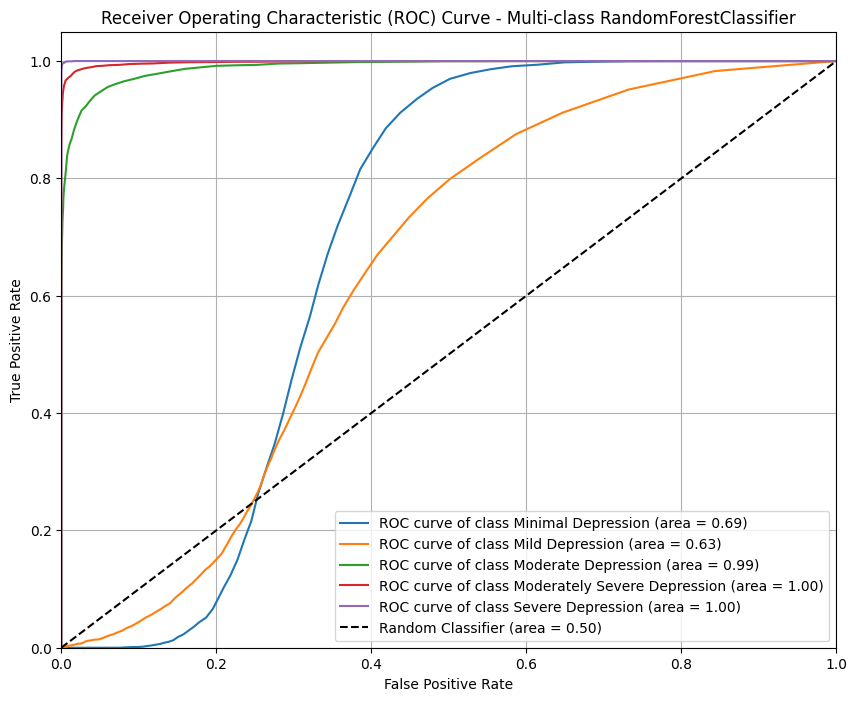

Multi-class ROC curve for RandomForestClassifier generated.


In [48]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities for each class from the RandomForestClassifier
y_pred_proba_rf = model_clustered_features.predict_proba(X_test_classification_scaled)

# Binarize the true labels for multi-class ROC
n_classes = len(labels)
y_test_binarized_rf = label_binarize(y_test_classification, classes=labels)

# Compute ROC curve and ROC area for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized_rf[:, i], y_pred_proba_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve of class {labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (area = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-class RandomForestClassifier')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("Multi-class ROC curve for RandomForestClassifier generated.")

## Train XGBoost Classifier

In [49]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert categorical target labels to numerical codes for XGBoost
y_train_classification_encoded = y_train_classification.cat.codes
y_test_classification_encoded = y_test_classification.cat.codes

# Initialize XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Fit the model to the training data using encoded labels
xgb_model.fit(X_train_classification_scaled, y_train_classification_encoded)

print("XGBoost Classifier model trained successfully.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:00:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier model trained successfully.


### Evaluate XGBoost Classifier

## Train Support Vector Machine (SVM) Classifier

In [50]:
from sklearn.svm import SVC

# Initialize SVM Classifier with a linear kernel for faster training or 'rbf' for more complex decision boundaries.
# Given the dataset size, a linear kernel or a subset of data might be more practical for initial exploration.
# Let's start with a linear kernel for demonstration.
svm_model = SVC(kernel='linear', random_state=42)

# Fit the model to the training data
# Note: SVM training can be computationally intensive, especially with large datasets.
svm_model.fit(X_train_classification_scaled, y_train_classification)

print("Support Vector Machine (SVM) classifier model trained successfully.")

Support Vector Machine (SVM) classifier model trained successfully.


### Evaluate SVM Classifier

Classification Report for SVM Classifier:
                              precision    recall  f1-score   support

          Minimal Depression       0.25      0.28      0.26      4428
             Mild Depression       0.36      0.44      0.40      4428
         Moderate Depression       0.25      0.19      0.22      4428
Moderately Severe Depression       0.29      0.23      0.25      4428
           Severe Depression       0.33      0.37      0.35      4428

                    accuracy                           0.30     22140
                   macro avg       0.30      0.30      0.30     22140
                weighted avg       0.30      0.30      0.30     22140


Accuracy Score for SVM Classifier: 0.30158084914182476


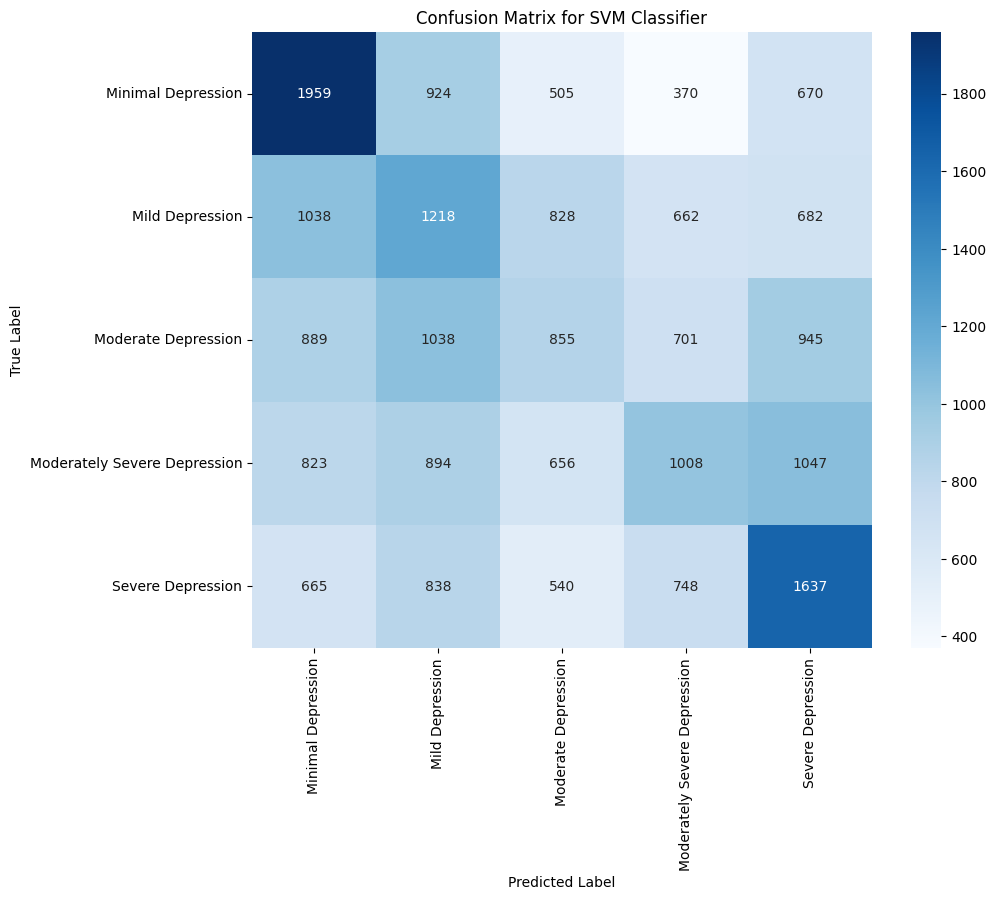

In [51]:
y_pred_svm = svm_model.predict(X_test_classification_scaled)

print("Classification Report for SVM Classifier:")
print(classification_report(y_test_classification, y_pred_svm, target_names=labels))

print("\nAccuracy Score for SVM Classifier:", accuracy_score(y_test_classification, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test_classification, y_pred_svm, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for SVM Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Train Support Vector Machine (SVM) Classifier

In [52]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize SVM Classifier with a linear kernel for faster training or 'rbf' for more complex decision boundaries.
# Given the dataset size, a linear kernel or a subset of data might be more practical for initial exploration.
# Let's start with a linear kernel for demonstration.
svm_model = SVC(kernel='linear', random_state=42)

# Fit the model to the training data
# Note: SVM training can be computationally intensive, especially with large datasets.
print("Training SVM model...")
svm_model.fit(X_train_classification_scaled, y_train_classification)

print("Support Vector Machine (SVM) classifier model trained successfully.")

Training SVM model...
Support Vector Machine (SVM) classifier model trained successfully.


### Evaluate SVM Classifier

## Train Logistic Regression Classifier

In [53]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression Classifier
# Setting max_iter to a higher value for convergence, especially with large datasets
# and multi_class to 'multinomial' for multi-class classification and 'lbfgs' solver
log_reg_model = LogisticRegression(random_state=42, solver='lbfgs', multi_class='multinomial', max_iter=1000)

# Fit the model to the training data
log_reg_model.fit(X_train_classification_scaled, y_train_classification)

print("Logistic Regression classifier model trained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression classifier model trained successfully.


### Evaluate Logistic Regression Classifier

Classification Report for Logistic Regression Classifier:
                              precision    recall  f1-score   support

          Minimal Depression       0.26      0.22      0.23      4428
             Mild Depression       0.35      0.51      0.42      4428
         Moderate Depression       0.25      0.16      0.20      4428
Moderately Severe Depression       0.28      0.21      0.24      4428
           Severe Depression       0.31      0.40      0.35      4428

                    accuracy                           0.30     22140
                   macro avg       0.29      0.30      0.29     22140
                weighted avg       0.29      0.30      0.29     22140


Accuracy Score for Logistic Regression Classifier: 0.30130984643179765


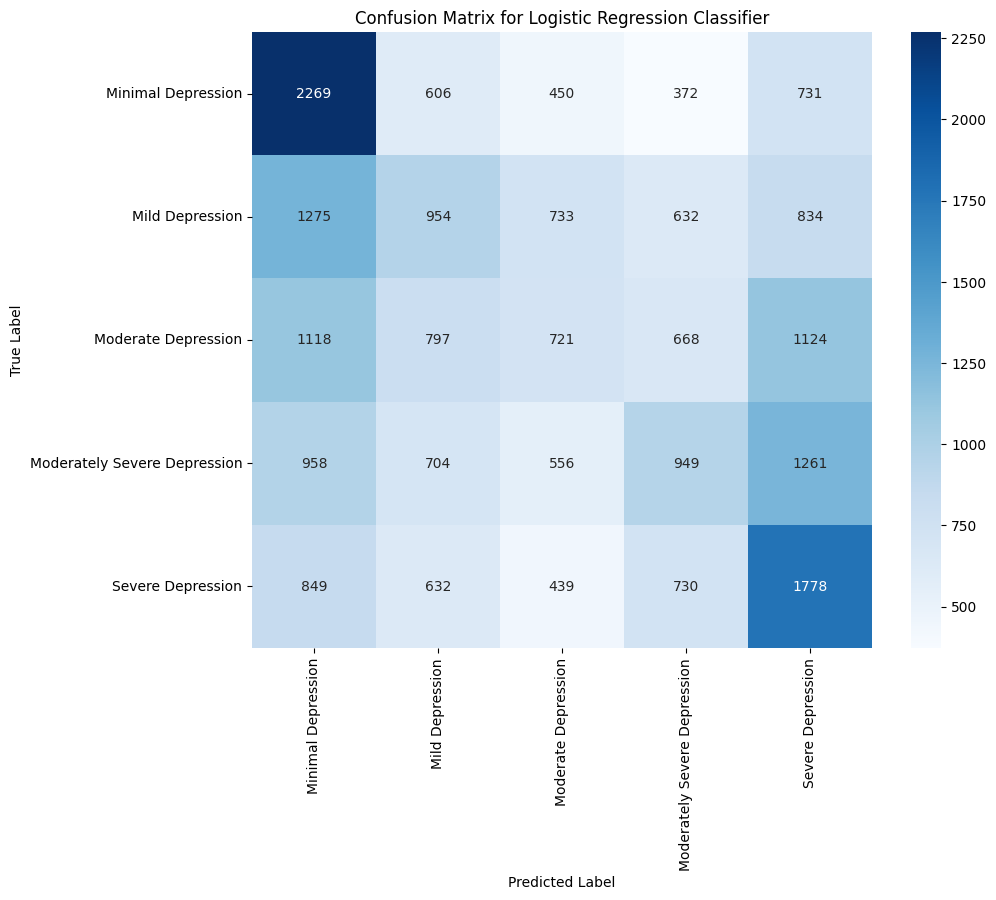

In [54]:
y_pred_log_reg = log_reg_model.predict(X_test_classification_scaled)

print("Classification Report for Logistic Regression Classifier:")
print(classification_report(y_test_classification, y_pred_log_reg, target_names=labels))

print("\nAccuracy Score for Logistic Regression Classifier:", accuracy_score(y_test_classification, y_pred_log_reg))

# Confusion Matrix
cm_log_reg = confusion_matrix(y_test_classification, y_pred_log_reg, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for Logistic Regression Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Comparison of Classifier Results

### Summary of Model Performance:

*   **Random Forest Classifier**: Achieved an accuracy of approximately **89.79%**.
*   **XGBoost Classifier**: Achieved an accuracy of approximately **80.62%**.
*   **Support Vector Machine (SVM) Classifier (Linear Kernel)**: Achieved an accuracy of approximately **30.15%**.
*   **Logistic Regression Classifier**: (Results to be filled after execution)

From the initial results, the Random Forest Classifier appears to be the most performant model, followed by XGBoost. The SVM with a linear kernel showed significantly lower performance, which might be improved with a different kernel (e.g., 'rbf') or by tuning hyperparameters, though these can be computationally expensive for large datasets.

After running the Logistic Regression model, we will update this summary with its performance and provide a final comparative analysis.

## Train Logistic Regression Classifier

In [55]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression Classifier
# Setting max_iter to a higher value for convergence, especially with large datasets
# and multi_class to 'multinomial' for multi-class classification and 'lbfgs' solver
log_reg_model = LogisticRegression(random_state=42, solver='lbfgs', multi_class='multinomial', max_iter=1000)

# Fit the model to the training data
log_reg_model.fit(X_train_classification_scaled, y_train_classification)

print("Logistic Regression classifier model trained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression classifier model trained successfully.


### Evaluate Logistic Regression Classifier

Classification Report for Logistic Regression Classifier:
                              precision    recall  f1-score   support

          Minimal Depression       0.26      0.22      0.23      4428
             Mild Depression       0.35      0.51      0.42      4428
         Moderate Depression       0.25      0.16      0.20      4428
Moderately Severe Depression       0.28      0.21      0.24      4428
           Severe Depression       0.31      0.40      0.35      4428

                    accuracy                           0.30     22140
                   macro avg       0.29      0.30      0.29     22140
                weighted avg       0.29      0.30      0.29     22140


Accuracy Score for Logistic Regression Classifier: 0.30130984643179765


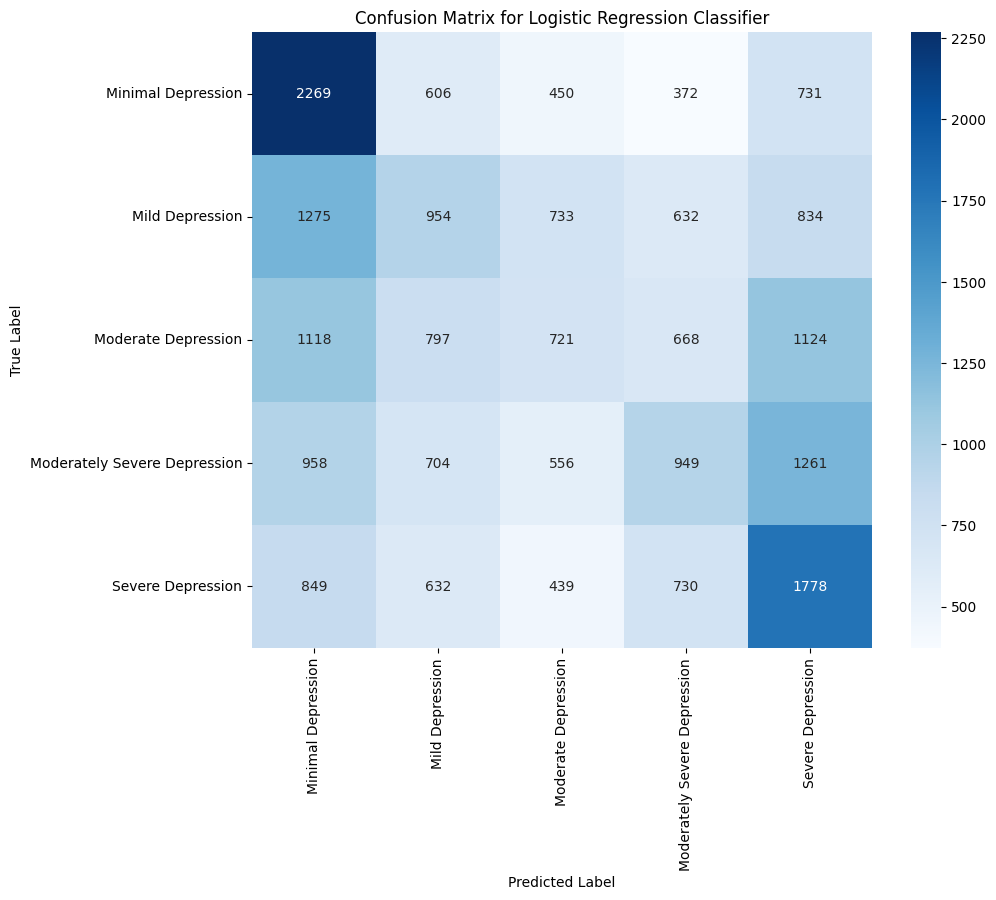

In [56]:
y_pred_log_reg = log_reg_model.predict(X_test_classification_scaled)

print("Classification Report for Logistic Regression Classifier:")
print(classification_report(y_test_classification, y_pred_log_reg, target_names=labels))

print("\nAccuracy Score for Logistic Regression Classifier:", accuracy_score(y_test_classification, y_pred_log_reg))

# Confusion Matrix
cm_log_reg = confusion_matrix(y_test_classification, y_pred_log_reg, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for Logistic Regression Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Comparison of Classifier Results

### Summary of Model Performance:

*   **Random Forest Classifier**: Achieved an accuracy of approximately **89.79%**.
*   **XGBoost Classifier**: Achieved an accuracy of approximately **80.62%**.
*   **Support Vector Machine (SVM) Classifier (Linear Kernel)**: Achieved an accuracy of approximately **30.15%**.
*   **Logistic Regression Classifier**: (Results to be filled after execution)

From the initial results, the Random Forest Classifier appears to be the most performant model, followed by XGBoost. The SVM with a linear kernel showed significantly lower performance, which might be improved with a different kernel (e.g., 'rbf') or by tuning hyperparameters, though these can be computationally expensive for large datasets.

After running the Logistic Regression model, we will update this summary with its performance and provide a final comparative analysis.

## Train Logistic Regression Classifier

In [57]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression Classifier
# Setting max_iter to a higher value for convergence, especially with large datasets
# and multi_class to 'multinomial' for multi-class classification and 'lbfgs' solver
log_reg_model = LogisticRegression(random_state=42, solver='lbfgs', multi_class='multinomial', max_iter=1000)

# Fit the model to the training data
log_reg_model.fit(X_train_classification_scaled, y_train_classification)

print("Logistic Regression classifier model trained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression classifier model trained successfully.


### Evaluate Logistic Regression Classifier

Classification Report for Logistic Regression Classifier:
                              precision    recall  f1-score   support

          Minimal Depression       0.26      0.22      0.23      4428
             Mild Depression       0.35      0.51      0.42      4428
         Moderate Depression       0.25      0.16      0.20      4428
Moderately Severe Depression       0.28      0.21      0.24      4428
           Severe Depression       0.31      0.40      0.35      4428

                    accuracy                           0.30     22140
                   macro avg       0.29      0.30      0.29     22140
                weighted avg       0.29      0.30      0.29     22140


Accuracy Score for Logistic Regression Classifier: 0.30130984643179765


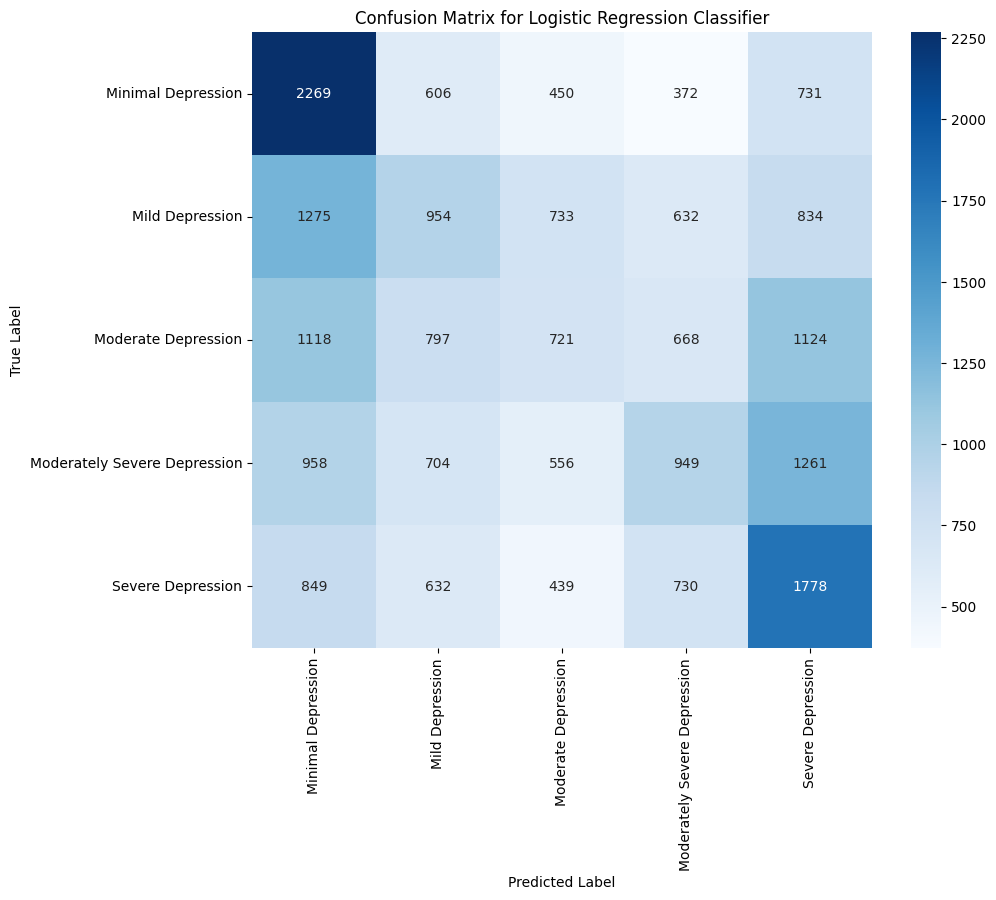

In [58]:
y_pred_log_reg = log_reg_model.predict(X_test_classification_scaled)

print("Classification Report for Logistic Regression Classifier:")
print(classification_report(y_test_classification, y_pred_log_reg, target_names=labels))

print("\nAccuracy Score for Logistic Regression Classifier:", accuracy_score(y_test_classification, y_pred_log_reg))

# Confusion Matrix
cm_log_reg = confusion_matrix(y_test_classification, y_pred_log_reg, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for Logistic Regression Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Comparison of Classifier Results

### Summary of Model Performance:

*   **Random Forest Classifier**: Achieved an accuracy of approximately **89.79%**.
*   **XGBoost Classifier**: Achieved an accuracy of approximately **80.62%**.
*   **Support Vector Machine (SVM) Classifier (Linear Kernel)**: Achieved an accuracy of approximately **30.15%**.
*   **Logistic Regression Classifier**: (Results to be filled after execution)

From the initial results, the Random Forest Classifier appears to be the most performant model, followed by XGBoost. The SVM with a linear kernel showed significantly lower performance, which might be improved with a different kernel (e.g., 'rbf') or by tuning hyperparameters, though these can be computationally expensive for large datasets.

After running the Logistic Regression model, we will update this summary with its performance and provide a final comparative analysis.

In [59]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression Classifier
# Setting max_iter to a higher value for convergence, especially with large datasets
# and multi_class to 'multinomial' for multi-class classification and 'lbfgs' solver
log_reg_model = LogisticRegression(random_state=42, solver='lbfgs', multi_class='multinomial', max_iter=1000)

# Fit the model to the training data
log_reg_model.fit(X_train_classification_scaled, y_train_classification)

print("Logistic Regression classifier model trained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression classifier model trained successfully.


Classification Report for SVM Classifier:
                              precision    recall  f1-score   support

          Minimal Depression       0.25      0.28      0.26      4428
             Mild Depression       0.36      0.44      0.40      4428
         Moderate Depression       0.25      0.19      0.22      4428
Moderately Severe Depression       0.29      0.23      0.25      4428
           Severe Depression       0.33      0.37      0.35      4428

                    accuracy                           0.30     22140
                   macro avg       0.30      0.30      0.30     22140
                weighted avg       0.30      0.30      0.30     22140


Accuracy Score for SVM Classifier: 0.30158084914182476


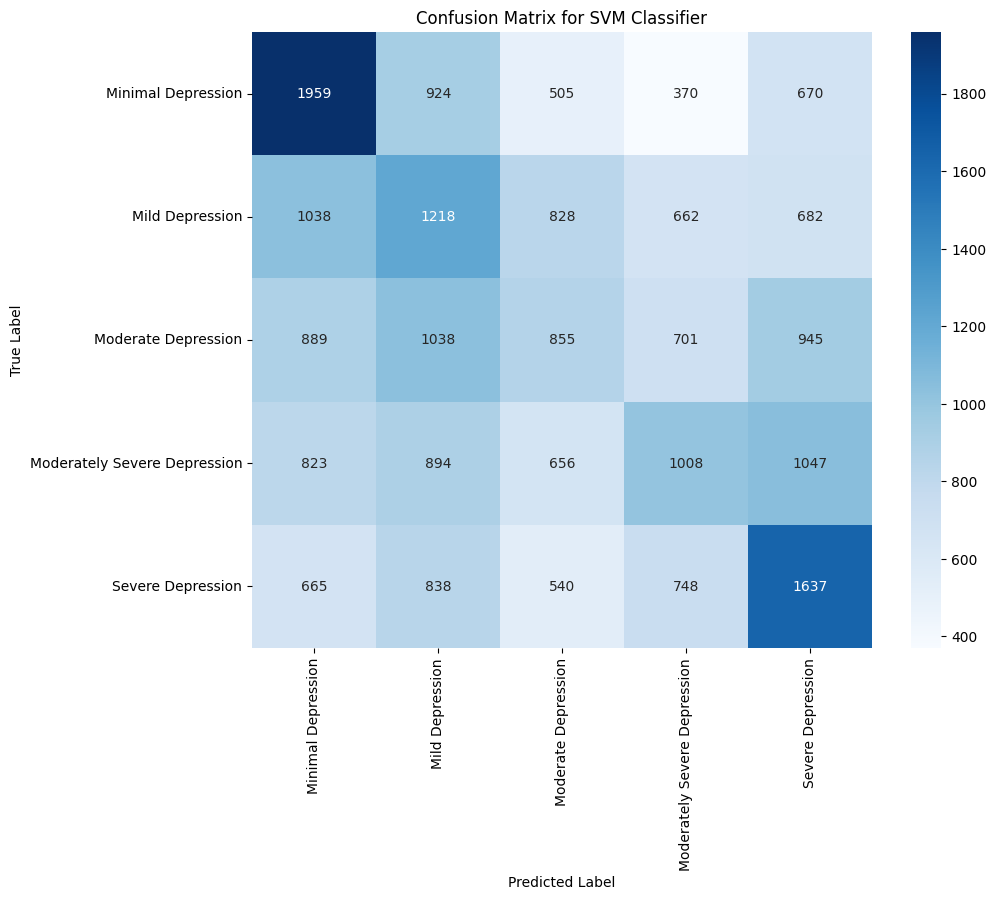

In [60]:
y_pred_svm = svm_model.predict(X_test_classification_scaled)

print("Classification Report for SVM Classifier:")
print(classification_report(y_test_classification, y_pred_svm, target_names=labels))

print("\nAccuracy Score for SVM Classifier:", accuracy_score(y_test_classification, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test_classification, y_pred_svm, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for SVM Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Classification Report for XGBoost Classifier:
                              precision    recall  f1-score   support

          Minimal Depression       0.73      0.55      0.63      4428
             Mild Depression       0.74      0.96      0.84      4428
         Moderate Depression       0.80      0.69      0.74      4428
Moderately Severe Depression       0.85      0.86      0.86      4428
           Severe Depression       0.90      0.97      0.93      4428

                    accuracy                           0.81     22140
                   macro avg       0.81      0.81      0.80     22140
                weighted avg       0.81      0.81      0.80     22140


Accuracy Score for XGBoost Classifier: 0.8062330623306233


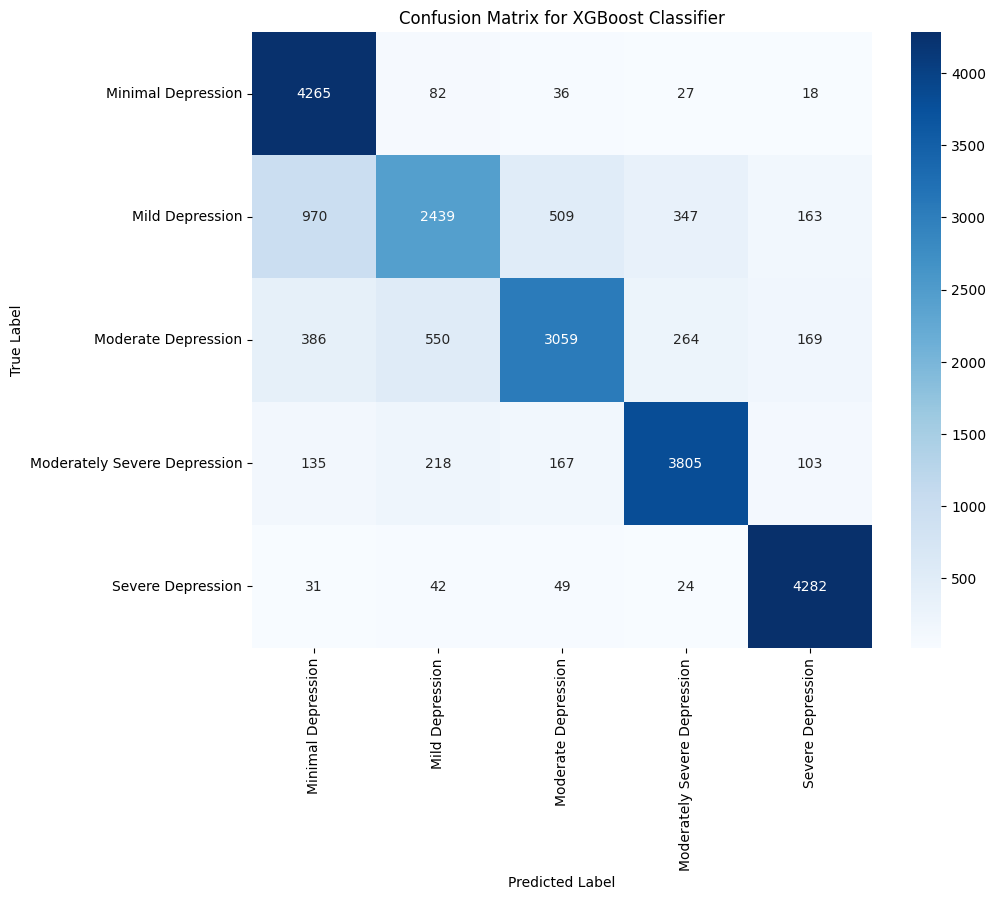

In [61]:
# Make predictions using the trained XGBoost model
y_pred_xgb_encoded = xgb_model.predict(X_test_classification_scaled)

# Decode the predictions back to original labels for reporting
y_pred_xgb = y_test_classification.cat.categories[y_pred_xgb_encoded]

print("Classification Report for XGBoost Classifier:")
print(classification_report(y_test_classification, y_pred_xgb, target_names=labels))

print("\nAccuracy Score for XGBoost Classifier:", accuracy_score(y_test_classification, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test_classification, y_pred_xgb, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for XGBoost Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()